# putEMG Dataset — Exploratory Data Analysis
**Task 1 | EMG Hand-Gesture Recognition | Surface-EMG, 44 subjects, 8 gestures**

## Cell 1 — Imports and Configuration

In [1]:
import gc, io, re, zipfile
from pathlib import Path
from urllib.parse import quote, unquote, urlparse
import xml.etree.ElementTree as ET

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from IPython.display import display

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Nextcloud connection 
HOST          = "https://chmura.put.poznan.pl"
SHARE_TOKEN   = "45NY5snj0U4tgQz"
WEBDAV_ROOT   = f"{HOST}/public.php/webdav"
REMOTE_FOLDER = "Data-CSV"
AUTH          = (SHARE_TOKEN, "")

#  Signal settings 
WINDOW_SIZE = 1024   # ~200 ms at 5120 Hz sampling rate
STEP_SIZE   = 512    # 50% overlap between consecutive windows

#  Gesture labels 
VALID_LABELS  = [0, 1, 2, 3, 6, 7, 8, 9]
GESTURE_NAMES = {
    0: "Idle",          1: "Fist",
    2: "Flexion",       3: "Extension",
    6: "Pinch-Index",   7: "Pinch-Middle",
    8: "Pinch-Ring",    9: "Pinch-Small",
}
FEATURE_METRICS = ["MAV", "RMS", "STD", "VAR", "WL", "ZC", "SSC", "IEMG"]

# Output paths 
FEATURE_FOLDER = Path("/kaggle/working/emg_features")
FEATURE_FOLDER.mkdir(parents=True, exist_ok=True)
LOG_PATH       = Path("/kaggle/working/extraction_log.csv")
RANDOM_STATE   = 42

print("Setup complete.")

Setup complete.


## Cell 2 — List Remote ZIP Files

In [2]:
propfind_body = """<?xml version="1.0" encoding="utf-8"?>
<d:propfind xmlns:d="DAV:">
  <d:prop><d:displayname/><d:getcontentlength/><d:resourcetype/></d:prop>
</d:propfind>"""

resp = requests.request(
    "PROPFIND",
    f"{WEBDAV_ROOT}/{quote(REMOTE_FOLDER, safe='/')}/",
    auth=AUTH,
    headers={"Depth": "1", "Content-Type": "application/xml"},
    data=propfind_body,
    timeout=120,
)
assert resp.status_code == 207, f"Expected 207, got {resp.status_code}"

DAV     = "{DAV:}"
records = []
for item in ET.fromstring(resp.content).findall(f"{DAV}response"):
    href = item.findtext(f"{DAV}href")
    name = Path(unquote(urlparse(href).path).rstrip("/")).name
    if name == REMOTE_FOLDER or not name.endswith(".zip"):
        continue
    if "emg_gestures" not in name.lower():
        continue
    size = int(item.findtext(f".//{DAV}getcontentlength") or 0)
    records.append({"name": name,
                    "remote_path": f"{REMOTE_FOLDER}/{name}",
                    "size_mb": round(size / 1024**2, 2)})

gesture_zips = pd.DataFrame(records).sort_values("name").reset_index(drop=True)
print(f"emg_gestures ZIP files found: {len(gesture_zips)}")

emg_gestures ZIP files found: 264


## Cell 3 — Single Download Loop: Extract Features + Collect Stats


In [3]:
def parse_name(name):
    """Return (subject_id, experiment_type) from a ZIP filename."""
    m = re.match(r"emg_gestures-(\d+)-([^-]+)-", name, re.I)
    return (int(m.group(1)), m.group(2)) if m else (-1, "Unknown")


def extract_features(window):
  
    d = np.diff(window, axis=0)

    return np.concatenate([
        np.abs(window).mean(axis=0),               # MAV
        np.sqrt(np.mean(window ** 2, axis=0)),     # RMS
        window.std(axis=0),                        # STD
        window.var(axis=0),                        # VAR
        np.abs(d).sum(axis=0),                     # WL
        ((window[:-1] * window[1:]) < 0).sum(0),  # ZC
        ((d[:-1] * d[1:]) < 0).sum(0),            # SSC
        np.abs(window).sum(axis=0),                # IEMG
    ]).astype("float32")


# Load checkpoint 
if LOG_PATH.exists():
    log_df = pd.read_csv(LOG_PATH)
    log_list = log_df.to_dict("records")

    done = set(
        log_df.loc[
            log_df["status"].eq("ok"),
            "name",
        ]
    )

    print(
        f"Checkpoint loaded — "
        f"{len(done)} / {len(gesture_zips)} files already done."
    )

else:
    log_list = []
    done = set()

    print("No checkpoint found — starting fresh.")


#  Main download and feature-extraction loop 
for idx, row in gesture_zips.iterrows():

    name = row["name"]
    out_pq = FEATURE_FOLDER / f"rec_{idx:04d}.parquet"

    zip_url = (
        f"{WEBDAV_ROOT}/"
        f"{quote(row['remote_path'], safe='/')}"
    )

    subject, exp_type = parse_name(name)

    # Skip files that were successfully processed previously
    if name in done and out_pq.exists():
        continue

    log_entry = {
        "name": name,
        "subject_id": subject,
        "experiment_type": exp_type,
        "raw_rows": 0,
        "windows": 0,
        "missing": 0,
        "duplicates": 0,
        "excluded_minus1": 0,
        "status": "pending",
    }

    try:
        #  Download ZIP file 
        r = requests.get(
            zip_url,
            auth=AUTH,
            timeout=180,
        )

        r.raise_for_status()

        frames = []

        # Open ZIP file in memory 
        with zipfile.ZipFile(io.BytesIO(r.content)) as zf:

            csv_names = [
                file_name
                for file_name in zf.namelist()
                if file_name.lower().endswith(".csv")
            ]

            for csv_name in csv_names:

                #  Read only the header first 
                with zf.open(csv_name) as fh:
                    header = pd.read_csv(
                        fh,
                        nrows=0,
                    ).columns.tolist()

                # Identify and numerically sort the 24 EMG columns
                emg_cols = sorted(
                    [
                        col
                        for col in header
                        if re.fullmatch(r"EMG_\d+", col, re.I)
                    ],
                    key=lambda col: int(
                        re.search(r"\d+", col).group()
                    ),
                )

                # Ignore CSV files without the required columns
                if "TRAJ_GT" not in header or len(emg_cols) != 24:
                    continue

                dtype_map = {
                    col: "float32"
                    for col in emg_cols + ["TRAJ_GT"]
                }

                #  Read required columns 
                with zf.open(csv_name) as fh:
                    df = pd.read_csv(
                        fh,
                        usecols=emg_cols + ["TRAJ_GT"],
                        dtype=dtype_map,
                        low_memory=False,
                    )

                #  Collect raw-data statistics 
                log_entry["raw_rows"] += len(df)

                log_entry["missing"] += int(
                    df.isna().sum().sum()
                )

                log_entry["duplicates"] += int(
                    pd.util.hash_pandas_object(
                        df,
                        index=False,
                    )
                    .duplicated()
                    .sum()
                )

                # Convert ground-truth labels to integer array
                labels = (
                    pd.to_numeric(
                        df["TRAJ_GT"],
                        errors="coerce",
                    )
                    .fillna(-999)
                    .astype(int)
                    .to_numpy()
                )

                log_entry["excluded_minus1"] += int(
                    (labels == -1).sum()
                )

                # Convert the EMG signals to a float32 NumPy array
                emg = df[emg_cols].to_numpy(
                    dtype="float32"
                )

                del df
                gc.collect()

                #  Define output columns 
                feat_col_names = [
                    f"{channel}_{metric}"
                    for metric in FEATURE_METRICS
                    for channel in emg_cols
                ]

                meta_col_names = [
                    "subject_id",
                    "label",
                    "gesture_name",
                    "experiment_type",
                    "source_zip",
                    "source_csv",
                    "segment_id",
                    "window_start",
                ]

                # Identify boundaries where the gesture label changes
                bounds = np.flatnonzero(
                    np.r_[
                        True,
                        labels[1:] != labels[:-1],
                        True,
                    ]
                )

                rows = []

                #  Process each continuous label segment 
                for segment_id in range(len(bounds) - 1):

                    start = int(bounds[segment_id])
                    end = int(bounds[segment_id + 1])
                    label = int(labels[start])

                    # Keep only the selected gesture classes
                    if label not in VALID_LABELS:
                        continue

                    # Ignore segments shorter than one complete window
                    if (end - start) < WINDOW_SIZE:
                        continue

                    #  Sliding-window feature extraction 
                    for window_start in range(
                        start,
                        end - WINDOW_SIZE + 1,
                        STEP_SIZE,
                    ):

                        window = emg[
                            window_start:
                            window_start + WINDOW_SIZE
                        ]

                        # Do not extract features from incomplete data
                        if np.isnan(window).any():
                            continue

                        feature_values = extract_features(
                            window
                        ).tolist()

                        rows.append(
                            [
                                subject,
                                label,
                                GESTURE_NAMES.get(
                                    label,
                                    str(label),
                                ),
                                exp_type,
                                name,
                                csv_name,
                                segment_id,
                                window_start,
                            ]
                            + feature_values
                        )

                del emg
                del labels
                gc.collect()

                # Add the current CSV output to the ZIP-level list
                if rows:
                    csv_feature_df = pd.DataFrame(
                        rows,
                        columns=(
                            meta_col_names
                            + feat_col_names
                        ),
                    )

                    frames.append(csv_feature_df)

        #  Confirm that the ZIP produced valid windows 
        if not frames:
            log_entry["status"] = "no valid windows"
        else:
            out_df = pd.concat(frames, ignore_index=True)

            out_df["label"]      = out_df["label"].astype("int8")
            out_df["subject_id"] = out_df["subject_id"].astype("int16")
            out_df["segment_id"] = out_df["segment_id"].astype("int16")
            out_df["window_start"] = out_df["window_start"].astype("int32")

            out_df.to_parquet(out_pq, index=False)

            log_entry["windows"] = len(out_df)
            log_entry["status"]  = "ok"

            del out_df
            gc.collect()

    except Exception as err:
        log_entry["status"] = f"error: {err}"

    #  Save checkpoint after every ZIP file 
    log_list = [
        previous_entry
        for previous_entry in log_list
        if previous_entry["name"] != name
    ]

    log_list.append(log_entry)

    pd.DataFrame(log_list).to_csv(
        LOG_PATH,
        index=False,
    )

    gc.collect()


#  Load final extraction log 
log_df = pd.read_csv(LOG_PATH)

current_names = set(
    gesture_zips["name"]
)

current_log = log_df[
    log_df["name"].isin(current_names)
].copy()

ok = current_log["status"].eq("ok")


#  Final extraction summary 
print(f"Total ZIP files    : {len(gesture_zips)}")
print(f"Successfully done  : {int(ok.sum())}")
print(
    f"Total raw rows     : "
    f"{current_log['raw_rows'].sum():,.0f}"
)
print(
    f"Total windows      : "
    f"{current_log['windows'].sum():,.0f}"
)


#  Validate log coverage 
missing_log_entries = (
    current_names
    - set(current_log["name"])
)

failed_files = current_log[
    ~current_log["status"].eq("ok")
]


# Expected output file for every discovered ZIP
expected_parquet_files = [
    FEATURE_FOLDER / f"rec_{idx:04d}.parquet"
    for idx in gesture_zips.index
]

missing_parquet_files = [
    str(path)
    for path in expected_parquet_files
    if not path.exists()
]


assert not missing_log_entries, (
    "Some ZIP files are missing from the extraction log:\n"
    + "\n".join(sorted(missing_log_entries))
)


assert failed_files.empty, (
    "Some ZIP files failed during extraction:\n"
    + failed_files[
        ["name", "status"]
    ].to_string(index=False)
)


assert not missing_parquet_files, (
    "Some expected parquet files are missing:\n"
    + "\n".join(missing_parquet_files)
)


print(
    "Validation passed: every discovered gesture ZIP "
    "produced an output parquet file."
)

Checkpoint loaded — 264 / 264 files already done.
Total ZIP files    : 264
Successfully done  : 264
Total raw rows     : 394,589,696
Total windows      : 619,479
Validation passed: every discovered gesture ZIP produced an output parquet file.


## Cell 4 — Load Feature Dataset

In [4]:
parquet_files = sorted(FEATURE_FOLDER.glob("rec_*.parquet"))
print(f"Loading {len(parquet_files)} parquet files ...")

feature_df = pd.concat(
    [pd.read_parquet(f) for f in parquet_files],
    ignore_index=True
)

# Identify the 192 extracted feature columns
FEAT_PAT  = re.compile(r"EMG_\d+_(MAV|RMS|STD|VAR|WL|ZC|SSC|IEMG)", re.I)
feat_cols = [c for c in feature_df.columns if FEAT_PAT.fullmatch(c)]

assert len(feat_cols) == 192, (
    f"Expected 192 feature columns, but found {len(feat_cols)}."
)

observed_labels = set(
    feature_df["label"].astype(int).unique()
)

expected_labels = set(VALID_LABELS)

assert observed_labels == expected_labels, (
    f"Expected labels {sorted(expected_labels)}, "
    f"but found {sorted(observed_labels)}."
)

assert feature_df["subject_id"].nunique() == 44, (
    f"Expected 44 subjects, but found "
    f"{feature_df['subject_id'].nunique()}."
)

# Memory: convert repeated-string columns to category
for col in [
    "gesture_name",
    "experiment_type",
    "source_zip",
    "source_csv",
]:
    if col in feature_df.columns:
        feature_df[col] = feature_df[col].astype("category")
# Numeric view of feature columns (used throughout EDA)
num_df = feature_df[feat_cols].apply(pd.to_numeric, errors="coerce")

print(f"Shape        : {feature_df.shape}")
print(f"Feature cols : {len(feat_cols)}")
print(f"Subjects     : {feature_df['subject_id'].nunique()}")
print(f"Classes      : {sorted(feature_df['label'].unique())}")

Loading 264 parquet files ...
Shape        : (619479, 196)
Feature cols : 192
Subjects     : 44
Classes      : [np.int8(0), np.int8(1), np.int8(2), np.int8(3), np.int8(6), np.int8(7), np.int8(8), np.int8(9)]



## A — Summary Table

In [5]:
cc = feature_df["label"].value_counts().sort_index()

summary = pd.DataFrame([{
    "Name"             : "putEMG 24-channel hand-gesture dataset",
    "Source"           : "Poznan University of Technology — Nextcloud public share",
    "Area"             : "Surface-EMG hand-gesture recognition",
    "ZIP/trial files": len(gesture_zips),
    "Raw signal rows": f"{int(current_log['raw_rows'].sum()):,}",
    "Window samples"   : f"{len(feature_df):,}",
    "Subjects"         : feature_df['subject_id'].nunique(),
    "Classes"          : f"{feature_df['label'].nunique()} — {sorted(feature_df['label'].unique().tolist())}",
    "Feature count"    : len(feat_cols),
    "Feature types"    : "MAV, RMS, STD, VAR, WL, ZC, SSC, IEMG  ×  24 EMG channels",
    "Missing values"   : int(feature_df[feat_cols].isna().sum().sum()),
    "Duplicate windows": int(feature_df.duplicated(subset=feat_cols + ["label"]).sum()),
    "Imbalance ratio"  : f"{cc.max() / cc.min():.2f} : 1",
}]).T

summary.columns    = ["Value"]
summary.index.name = "Property"
display(summary)

,Value
Property,
Name,putEMG 24-channel hand-gesture dataset
Source,Poznan University of Technology — Nextcloud pu...
Area,Surface-EMG hand-gesture recognition
ZIP/trial files,264
Raw signal rows,"394,589,696"
Window samples,"619,479"
Subjects,44
Classes,"8 — [0, 1, 2, 3, 6, 7, 8, 9]"
Feature count,192



## B — Descriptive Statistics

In [6]:
# Pre-compute IQR bounds (reused in C and throughout)
q1  = num_df.quantile(0.25)
q3  = num_df.quantile(0.75)
iqr = q3 - q1
lo  = q1 - 1.5 * iqr
hi  = q3 + 1.5 * iqr
outlier_mask = num_df.lt(lo, axis=1) | num_df.gt(hi, axis=1)

stats = pd.DataFrame({
    "Mean"         : num_df.mean(),
    "Median"       : num_df.median(),
    "Std"          : num_df.std(),
    "Min"          : num_df.min(),
    "Q1"           : q1,
    "Q3"           : q3,
    "Max"          : num_df.max(),
    "Skewness"     : num_df.skew(),
    "Kurtosis"     : num_df.kurt(),
    "Outlier_count": outlier_mask.sum(),
    "Outlier_%"    : (outlier_mask.sum() / num_df.count() * 100).round(2),
})
stats.index.name = "Feature"
display(stats.round(4))

stats.to_csv("/kaggle/working/B_statistics.csv")
print("Saved → B_statistics.csv")

,Mean,Median,Std,Min,Q1,Q3,Max,Skewness,Kurtosis,Outlier_count,Outlier_%
Feature,,,,,,,,,,,
EMG_1_MAV,13.6593,10.7129,19.8489,2.5654,8.3823,13.9277,1.112246e+03,21.6109,715.8435,51542,8.32
EMG_2_MAV,13.6044,10.6680,15.5927,2.5010,8.5752,13.9854,1.569213e+03,22.7552,1196.2400,56410,9.11
EMG_3_MAV,13.3914,10.8291,13.8393,2.6182,8.7949,14.0068,1.044977e+03,18.9318,710.2904,54484,8.80
EMG_4_MAV,12.6118,10.5215,9.9520,2.0850,8.5918,13.6357,5.845400e+02,11.3780,278.0394,48301,7.80
EMG_5_MAV,13.0018,11.0225,9.1626,2.9453,8.9453,14.0645,4.763242e+02,7.9551,125.3937,47286,7.63
...,...,...,...,...,...,...,...,...,...,...,...
EMG_20_IEMG,11595.9799,8453.0000,16079.2503,1921.0000,6031.0000,12147.0000,7.540230e+05,12.2816,247.6602,47155,7.61
EMG_21_IEMG,11546.1203,8603.0000,14187.7837,1903.0000,6234.0000,12297.5000,6.475850e+05,11.0467,213.5336,47814,7.72
EMG_22_IEMG,12285.7739,8939.0000,16206.4482,1788.0000,6396.0000,12932.0000,8.543840e+05,13.3913,332.8858,50963,8.23


Saved → B_statistics.csv



## C — Data Quality

In [7]:
# C.1  Missing values
total_cells   = feature_df[feat_cols].size
total_missing = int(feature_df[feat_cols].isna().sum().sum())
print("C.1  Missing Values")
print(f"  Missing cells : {total_missing}  ({total_missing / total_cells * 100:.6f} %)")
print("  Effect: zero missing values means no imputation is needed before modelling.\n"
      if total_missing == 0 else
      "  Effect: must impute or drop rows before modelling.\n")

# C.2  Duplicate windows
dup_count = int(feature_df.duplicated(subset=feat_cols + ["label"]).sum())
if dup_count == 0:
    print("  Effect: no exact duplicate feature rows were found.")
else:
    print("  Effect: exact duplicates can bias evaluation and should be removed")
    print("  before constructing the final grouped data split.")

print("  Important: overlapping windows from the same recording are still highly")
print("  dependent even when they are not exact duplicates. All windows from the")
print("  same subject or source recording must remain in the same data split.\n")

# C.3  Near-constant features
print("C.3  Near-Constant Features")
nc_rows = []
for col in feat_cols:
    vals = num_df[col].dropna()
    dom  = vals.value_counts(normalize=True).iloc[0] * 100 if len(vals) else 0
    if vals.nunique() <= 1 or dom >= 99:
        nc_rows.append({"Feature": col, "Variance": round(vals.var(), 6), "Top_value_%": round(dom, 2)})
if nc_rows:
    display(pd.DataFrame(nc_rows))
    print("  Effect: constant features carry no information — drop before modelling.")
else:
    print("  None found — all features vary meaningfully.\n")

# C.4  Outliers
total_out = int(outlier_mask.sum().sum())
rows_out  = int(outlier_mask.any(axis=1).sum())
print("C.4  Outliers  (IQR rule: outside Q1 − 1.5·IQR  or  Q3 + 1.5·IQR)")
print(f"  Outlier cells         : {total_out:,}")
print(f"  Rows with ≥ 1 outlier : {rows_out:,}  ({rows_out / len(feature_df) * 100:.2f} %)")
print("  Effect: IQR-flagged values are statistical outliers, not automatically")
print("  measurement errors. EMG activity can naturally contain extreme values,")
print("  but flagged observations should be inspected by subject, gesture, channel,")
print("  and source recording before any removal or clipping.")
print("  Any scaler, clipping limit, or transformation must be fitted using only")
print("  the training data after the grouped train/test split.\n")

# C.5  Highly correlated features
print("C.5  Highly Correlated Features  (|r| > 0.90)  — full heatmap in Section F")
corr_sample = pd.concat(
    [g.sample(min(2000, len(g)), random_state=RANDOM_STATE)
     for _, g in feature_df.groupby("label", observed=True)],
    ignore_index=True,
)
corr_matrix = corr_sample[feat_cols].corr()
upper       = corr_matrix.abs().where(np.triu(np.ones(corr_matrix.shape, bool), k=1))
n_high      = int((upper > 0.90).sum().sum())
print(f"  Pairs with |r| > 0.90 : {n_high}")
print("  Effect: highly correlated features add little new information, increase")
print("  training time, and can cause multicollinearity in linear models.")
print("  Decision to remove should be validated via cross-validated model performance.")

C.1  Missing Values
  Missing cells : 0  (0.000000 %)
  Effect: zero missing values means no imputation is needed before modelling.

  Effect: no exact duplicate feature rows were found.
  Important: overlapping windows from the same recording are still highly
  dependent even when they are not exact duplicates. All windows from the
  same subject or source recording must remain in the same data split.

C.3  Near-Constant Features
  None found — all features vary meaningfully.

C.4  Outliers  (IQR rule: outside Q1 − 1.5·IQR  or  Q3 + 1.5·IQR)
  Outlier cells         : 8,768,426
  Rows with ≥ 1 outlier : 223,817  (36.13 %)
  Effect: IQR-flagged values are statistical outliers, not automatically
  measurement errors. EMG activity can naturally contain extreme values,
  but flagged observations should be inspected by subject, gesture, channel,
  and source recording before any removal or clipping.
  Any scaler, clipping limit, or transformation must be fitted using only
  the training dat


## D — Class Balance

,Label,Gesture,Windows,Percentage
0,0,Idle,380337,61.40
1,1,Fist,35638,5.75
2,2,Flexion,35356,5.71
3,3,Extension,34228,5.53
4,6,Pinch-Index,33649,5.43
5,7,Pinch-Middle,33552,5.42
6,8,Pinch-Ring,32920,5.31
7,9,Pinch-Small,33799,5.46


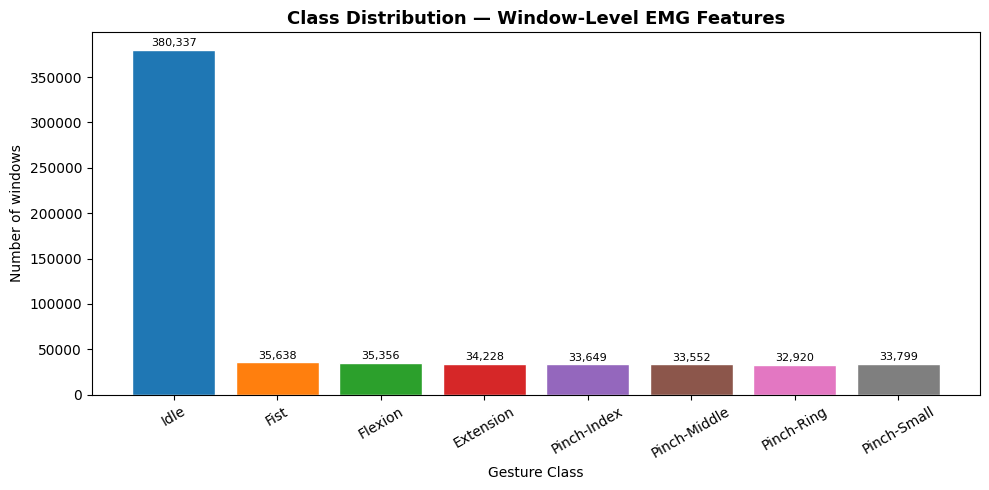

Imbalance ratio (largest / smallest): 11.55 : 1
Majority-class baseline: always predicting Idle would produce 61.40% accuracy.
Observed class imbalance level: substantial.

Effect on modelling metrics:
  • Accuracy should be reported together with macro-F1 and balanced accuracy.
  • Also report per-class precision, recall, F1, and the confusion matrix.
  • Class weighting or resampling is needed only if minority-class performance
    is poor, and it must be applied inside each training fold.
  • Subject/source grouping must be preserved during splitting and validation.


In [8]:
cc = feature_df["label"].value_counts().sort_index()
balance_df = pd.DataFrame({
    "Label"     : cc.index,
    "Gesture"   : [GESTURE_NAMES.get(int(l), str(l)) for l in cc.index],
    "Windows"   : cc.values,
    "Percentage": (cc.values / cc.sum() * 100).round(2),
})
display(balance_df)

# Bar chart
fig, ax = plt.subplots(figsize=(10, 5))
colors  = sns.color_palette("tab10", len(balance_df))
ax.bar(balance_df["Gesture"], balance_df["Windows"], color=colors, edgecolor="white")
for i, v in enumerate(balance_df["Windows"]):
    ax.text(i, v + cc.max() * 0.01, f"{v:,}", ha="center", fontsize=8)
ax.set_title("Class Distribution — Window-Level EMG Features", fontsize=13, fontweight="bold")
ax.set_xlabel("Gesture Class")
ax.set_ylabel("Number of windows")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

ratio = cc.max() / cc.min()

majority_label = int(cc.idxmax())
majority_name  = GESTURE_NAMES.get(majority_label, str(majority_label))
majority_count = int(cc.max())
majority_pct   = majority_count / cc.sum() * 100

print(f"Imbalance ratio (largest / smallest): {ratio:.2f} : 1")
print(
    f"Majority-class baseline: always predicting {majority_name} "
    f"would produce {majority_pct:.2f}% accuracy."
)

if ratio < 1.50:
    imbalance_level = "mild"
elif ratio < 3.00:
    imbalance_level = "moderate"
else:
    imbalance_level = "substantial"

print(f"Observed class imbalance level: {imbalance_level}.")
print()
print("Effect on modelling metrics:")
print("  • Accuracy should be reported together with macro-F1 and balanced accuracy.")
print("  • Also report per-class precision, recall, F1, and the confusion matrix.")
print("  • Class weighting or resampling is needed only if minority-class performance")
print("    is poor, and it must be applied inside each training fold.")
print("  • Subject/source grouping must be preserved during splitting and validation.")


## E — Feature Distributions

In [9]:
# One representative column per feature type (first available channel)
rep_features = []
for metric in FEATURE_METRICS:
    match = [c for c in feat_cols if c.endswith(f"_{metric}")]
    if match:
        rep_features.append(match[0])
print("Representative features selected:", rep_features)

# Stratified plotting sample — keeps all 8 classes equally represented
plot_df = pd.concat(
    [g.sample(min(2500, len(g)), random_state=RANDOM_STATE)
     for _, g in feature_df.groupby("label", observed=True)],
    ignore_index=True,
)
plot_df["Gesture"] = plot_df["label"].map(GESTURE_NAMES)
ordered_gestures  = [GESTURE_NAMES[l] for l in sorted(GESTURE_NAMES)
                     if GESTURE_NAMES[l] in plot_df["Gesture"].values]
print(f"Plotting sample: {len(plot_df):,} rows")

Representative features selected: ['EMG_1_MAV', 'EMG_1_RMS', 'EMG_1_STD', 'EMG_1_VAR', 'EMG_1_WL', 'EMG_1_ZC', 'EMG_1_SSC', 'EMG_1_IEMG']
Plotting sample: 20,000 rows


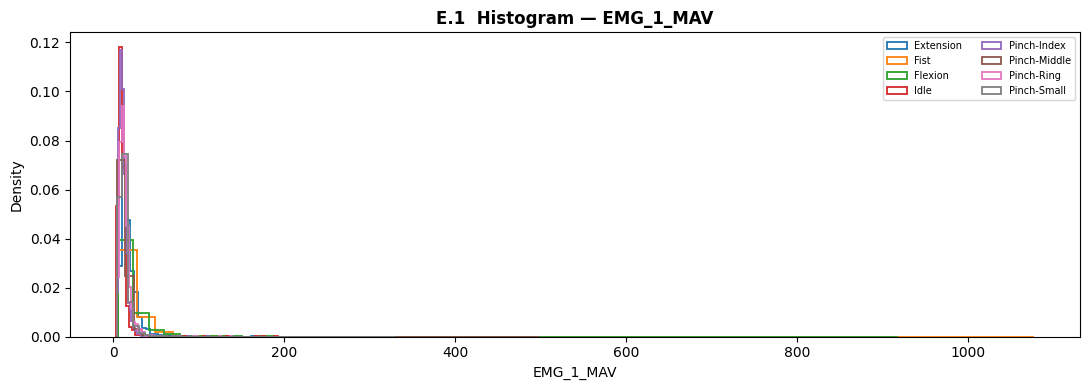

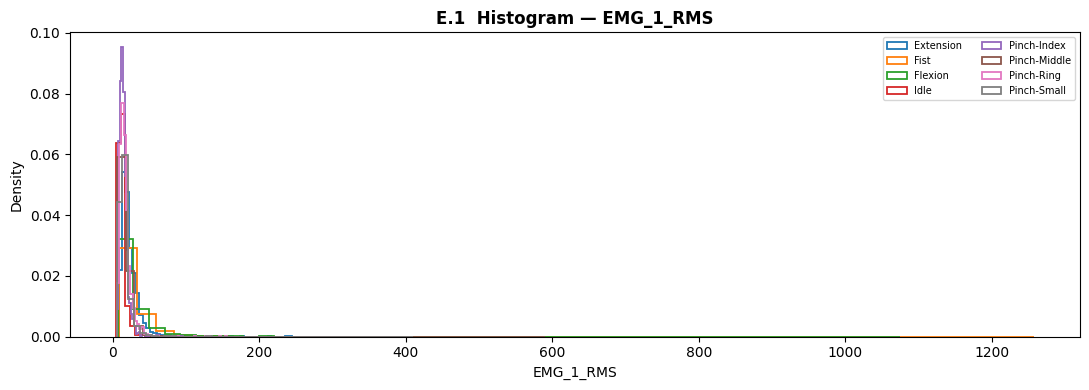

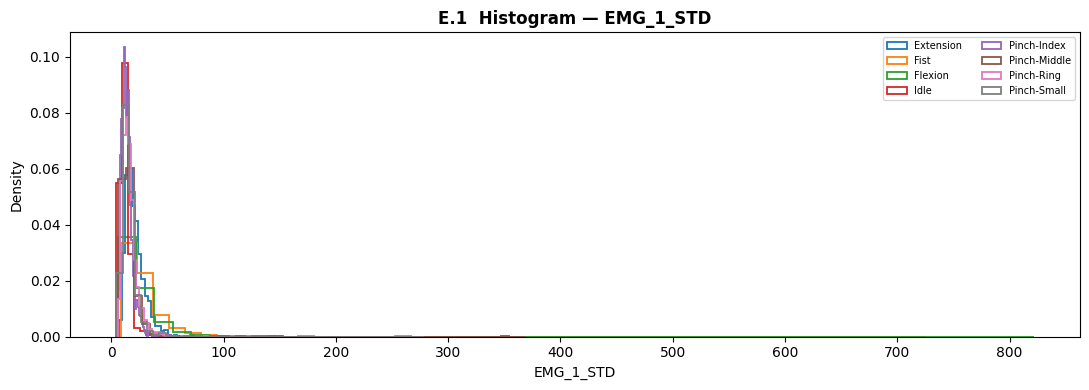

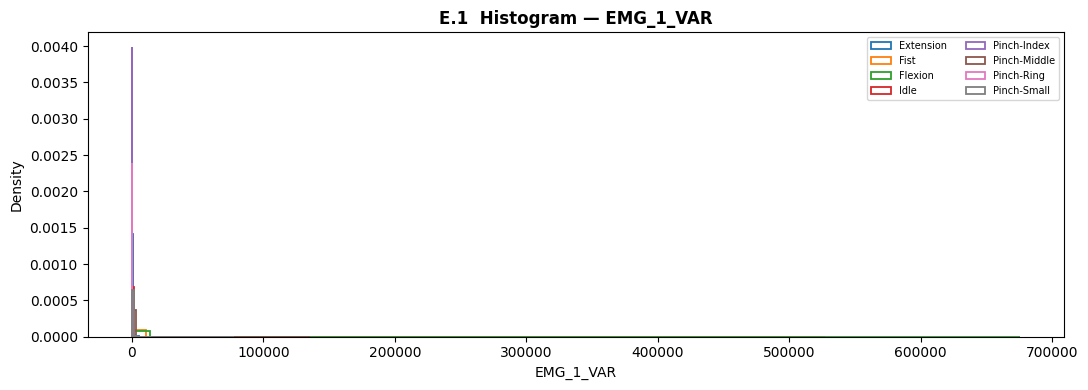

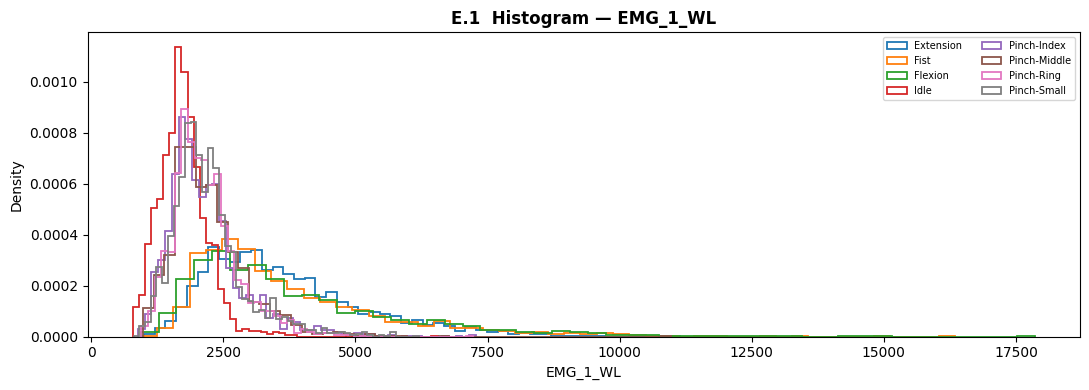

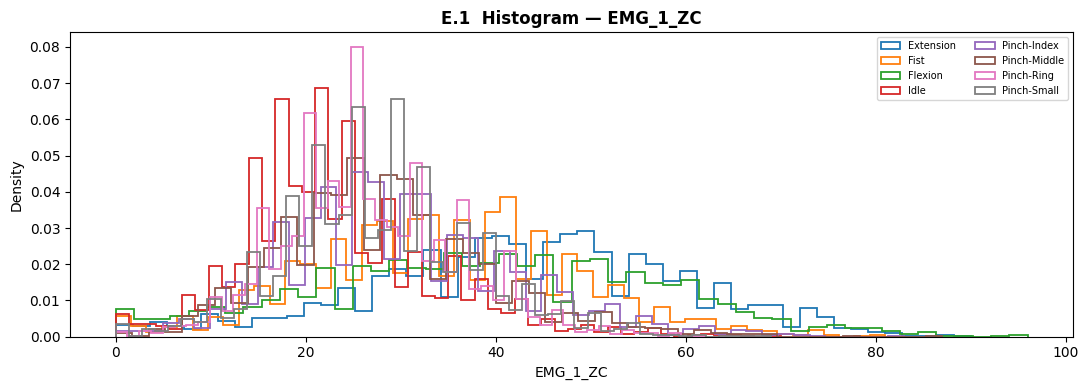

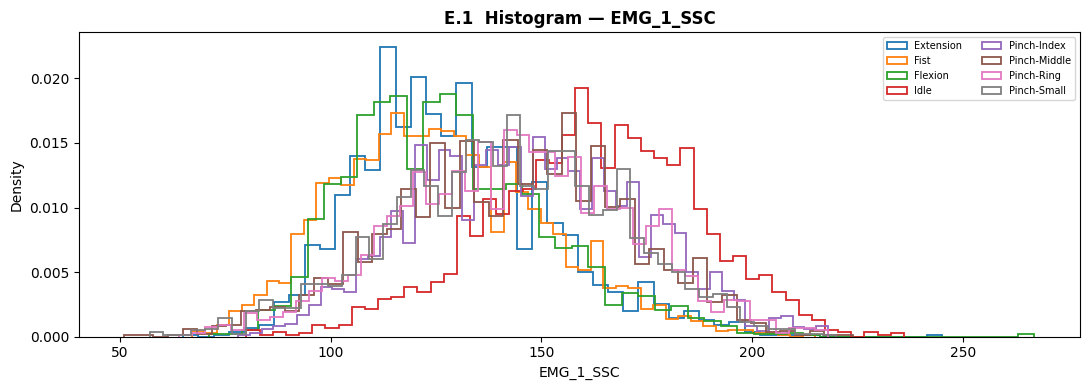

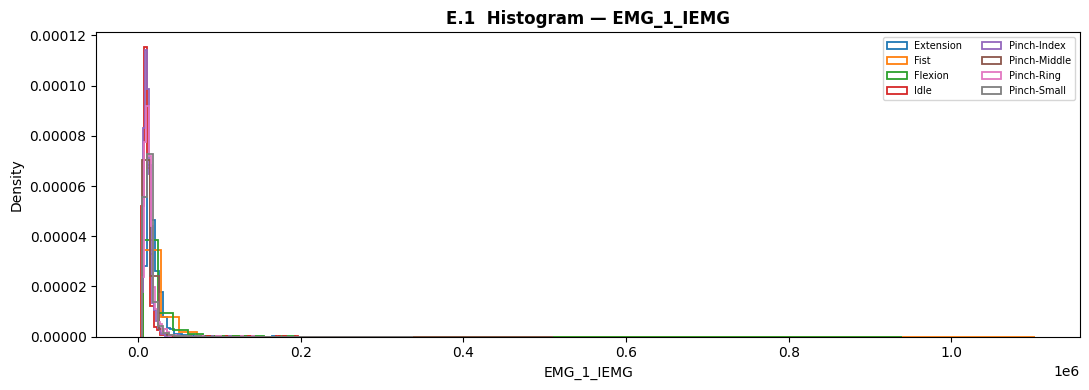

Reading: overlapping distributions mean that feature alone cannot separate
classes. The classifier must combine signals from multiple channels and metrics.


In [10]:
# E.1  Histograms
for feat in rep_features:
    fig, ax = plt.subplots(figsize=(11, 4))
    for gesture, grp in plot_df.groupby("Gesture", observed=True):
        ax.hist(grp[feat].dropna(), bins=50, histtype="step",
                density=True, label=gesture, linewidth=1.3)
    ax.set_title(f"E.1  Histogram — {feat}", fontsize=12, fontweight="bold")
    ax.set_xlabel(feat)
    ax.set_ylabel("Density")
    ax.legend(fontsize=7, ncol=2)
    plt.tight_layout()
    plt.show()

print("Reading: overlapping distributions mean that feature alone cannot separate")
print("classes. The classifier must combine signals from multiple channels and metrics.")

/tmp/ipykernel_58/81847546.py:6: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.



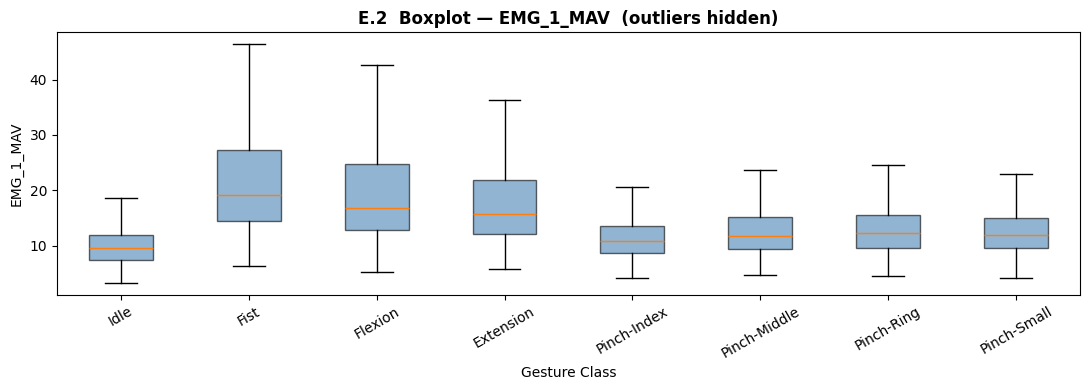

/tmp/ipykernel_58/81847546.py:6: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.



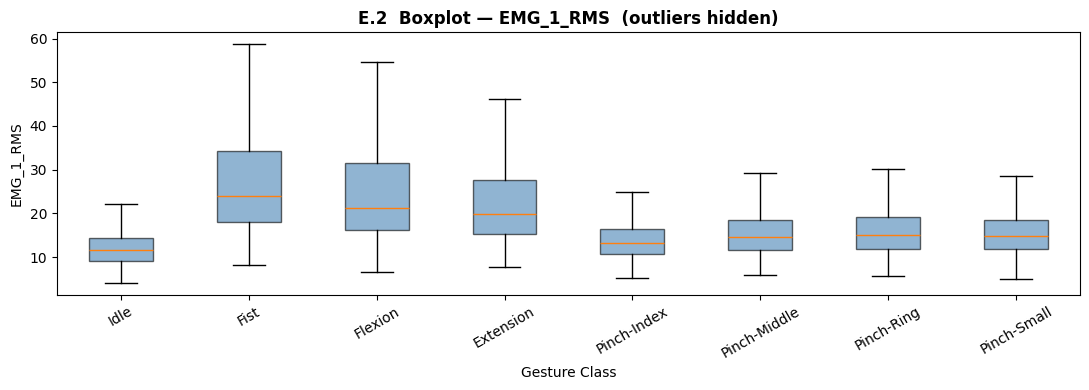

/tmp/ipykernel_58/81847546.py:6: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.



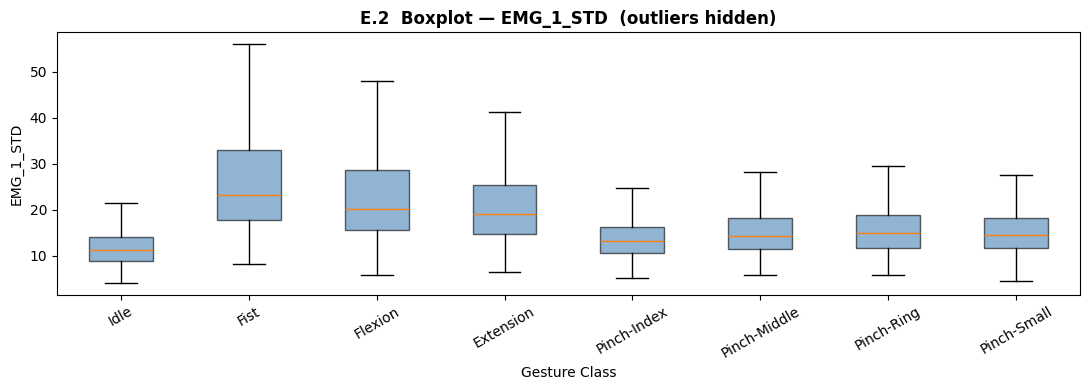

/tmp/ipykernel_58/81847546.py:6: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.



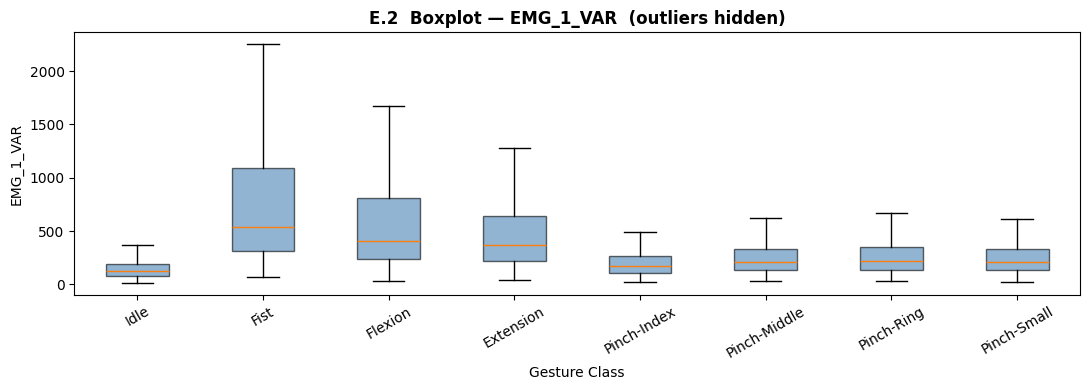

/tmp/ipykernel_58/81847546.py:6: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.



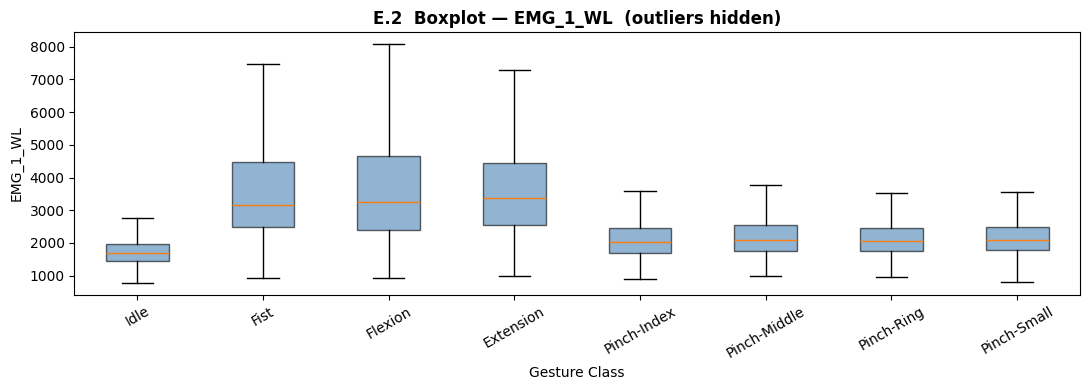

/tmp/ipykernel_58/81847546.py:6: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.



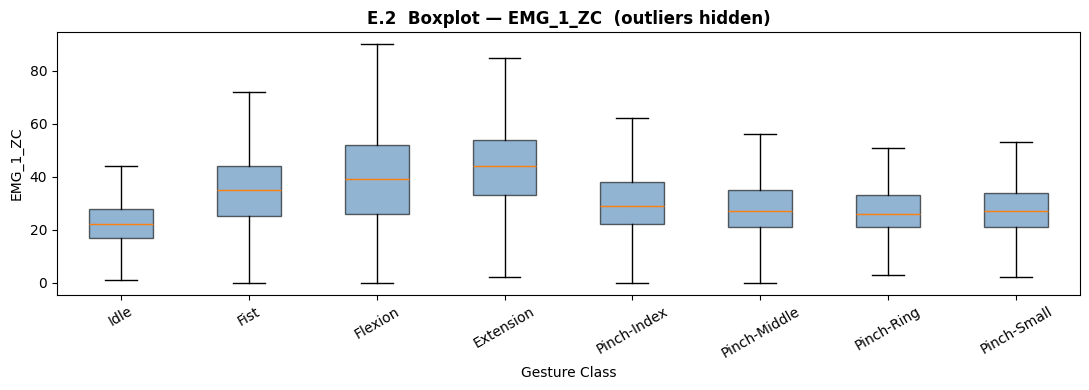

/tmp/ipykernel_58/81847546.py:6: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.



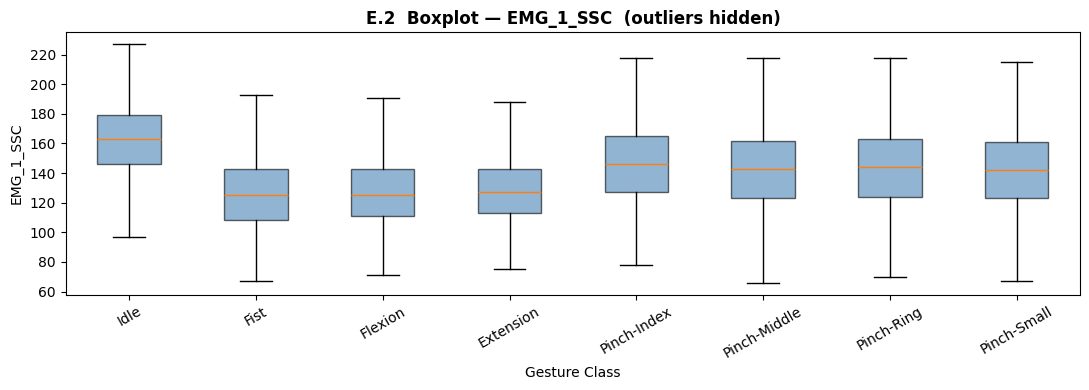

/tmp/ipykernel_58/81847546.py:6: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.



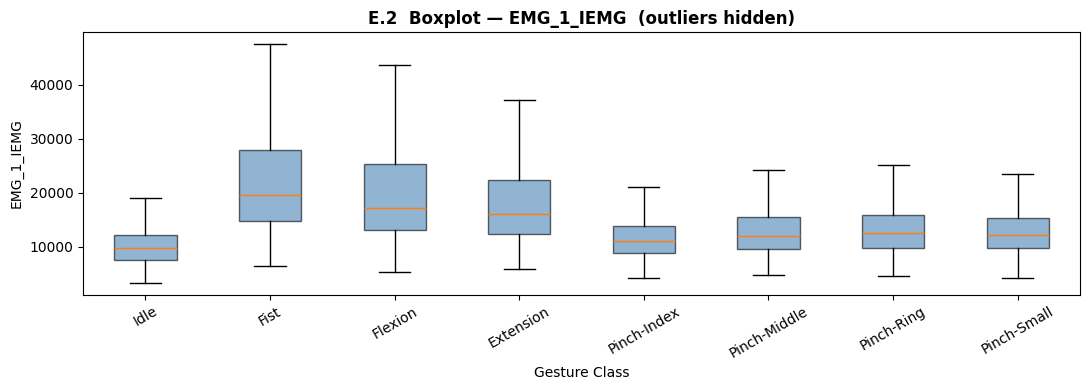

Reading: non-overlapping IQR boxes indicate the feature separates those classes
While, heavily overlapping boxes mean the feature alone is insufficient.


In [11]:
# E.2  Boxplots
for feat in rep_features:
    data   = [plot_df.loc[plot_df["Gesture"] == g, feat].dropna().values
               for g in ordered_gestures]
    fig, ax = plt.subplots(figsize=(11, 4))
    ax.boxplot(data, labels=ordered_gestures, showfliers=False, patch_artist=True,
               boxprops=dict(facecolor="steelblue", alpha=0.6))
    ax.set_title(f"E.2  Boxplot — {feat}  (outliers hidden)", fontsize=12, fontweight="bold")
    ax.set_xlabel("Gesture Class")
    ax.set_ylabel(feat)
    ax.tick_params(axis="x", rotation=30)
    plt.tight_layout()
    plt.show()

print("Reading: non-overlapping IQR boxes indicate the feature separates those classes")
print("While, heavily overlapping boxes mean the feature alone is insufficient.")

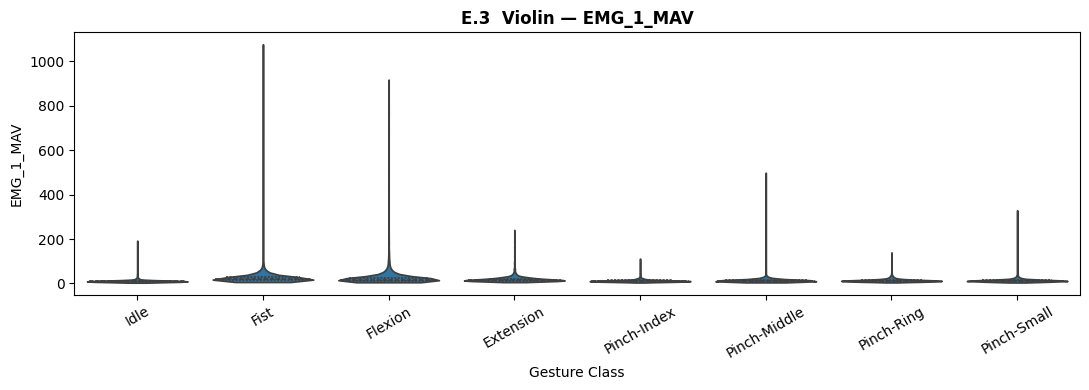

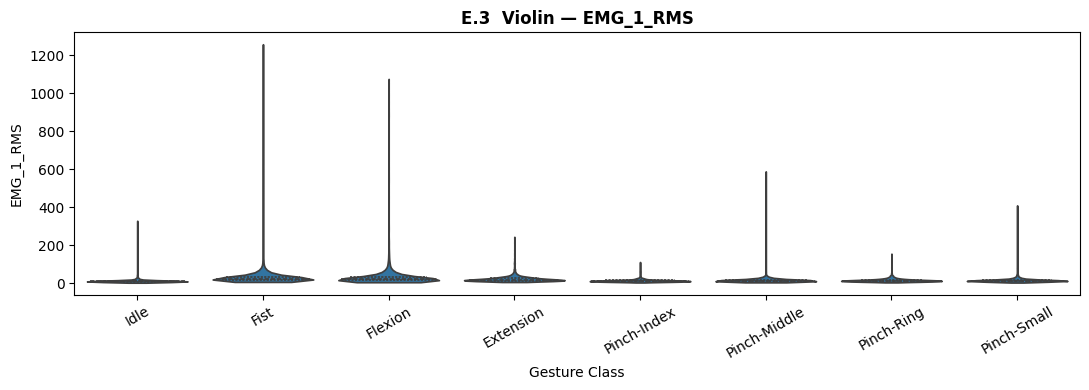

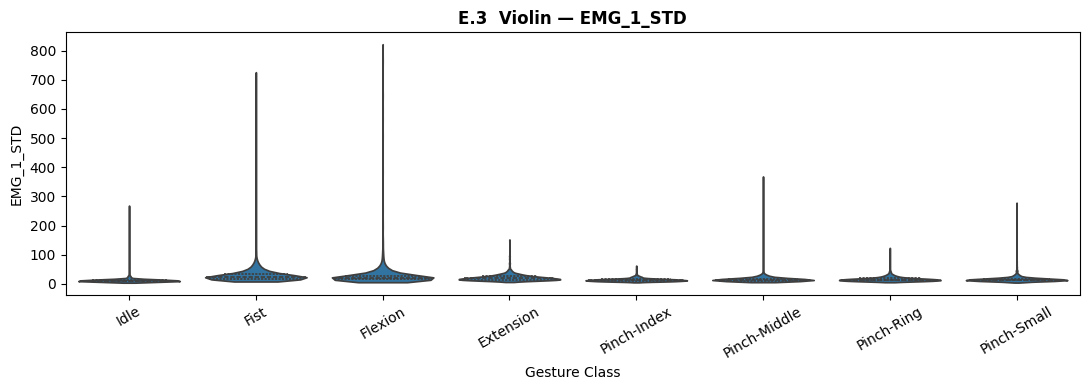

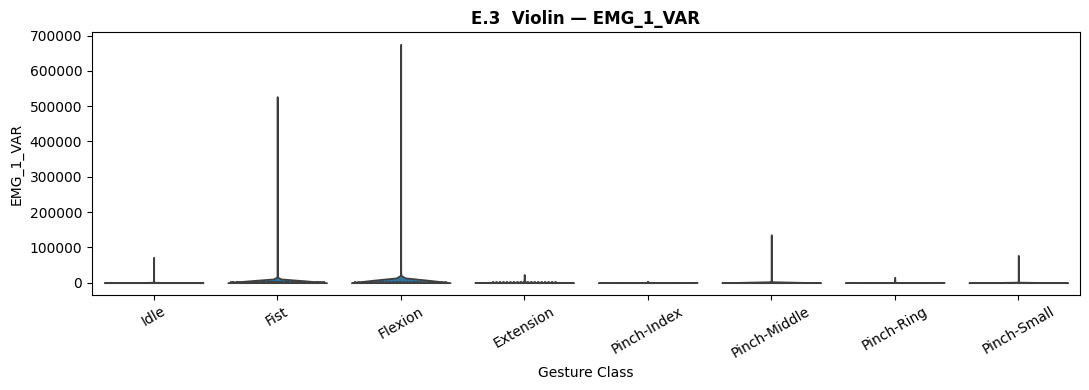

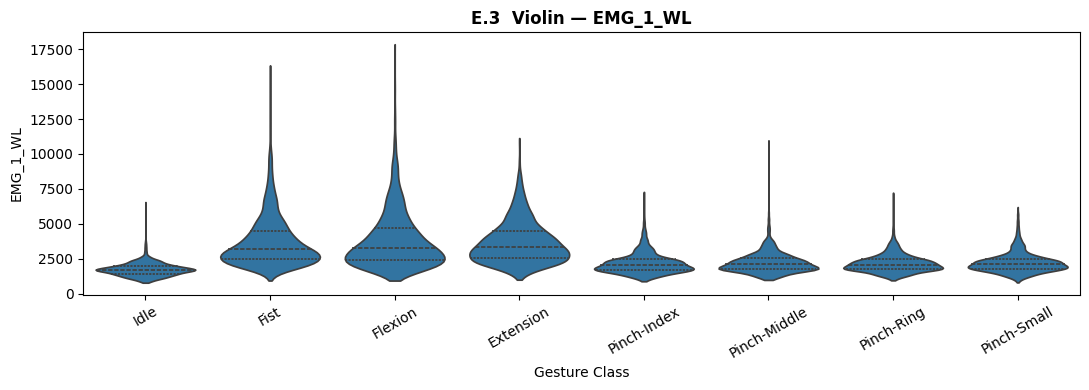

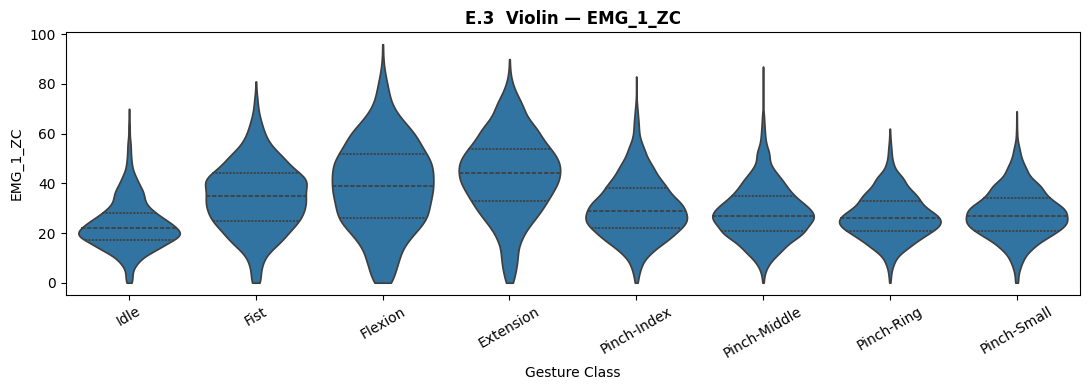

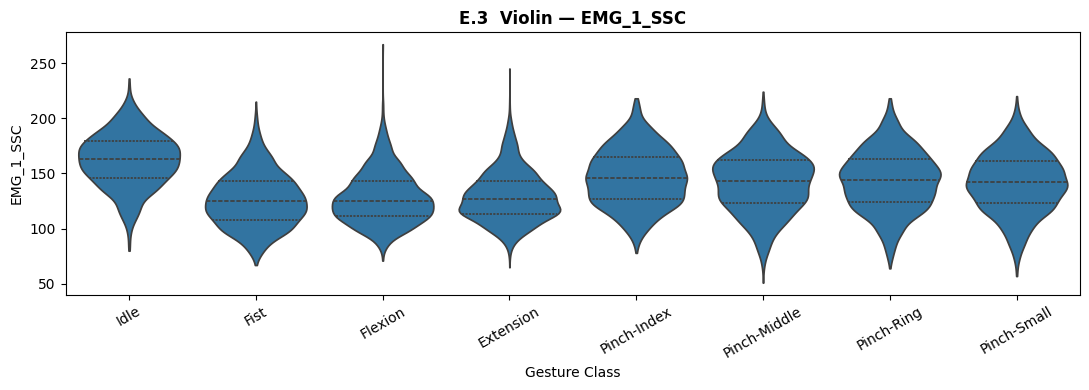

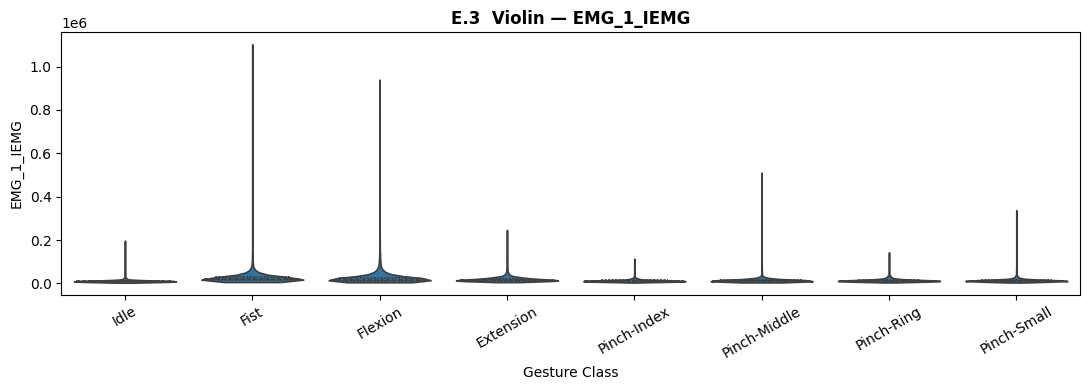

Reading: violin plots reveal the full distribution shape per class.
Different peak locations and narrow bodies = useful class separation.
Wide, similar shapes across classes = the classifier must combine many features.


In [12]:
# E.3  Violin plots
for feat in rep_features:
    fig, ax = plt.subplots(figsize=(11, 4))
    sns.violinplot(data=plot_df, x="Gesture", y=feat, order=ordered_gestures,
                   inner="quartile", cut=0, density_norm="width", ax=ax)
    ax.set_title(f"E.3  Violin — {feat}", fontsize=12, fontweight="bold")
    ax.set_xlabel("Gesture Class")
    ax.tick_params(axis="x", rotation=30)
    plt.tight_layout()
    plt.show()

print("Reading: violin plots reveal the full distribution shape per class.")
print("Different peak locations and narrow bodies = useful class separation.")
print("Wide, similar shapes across classes = the classifier must combine many features.")


## F — Correlation Analysis

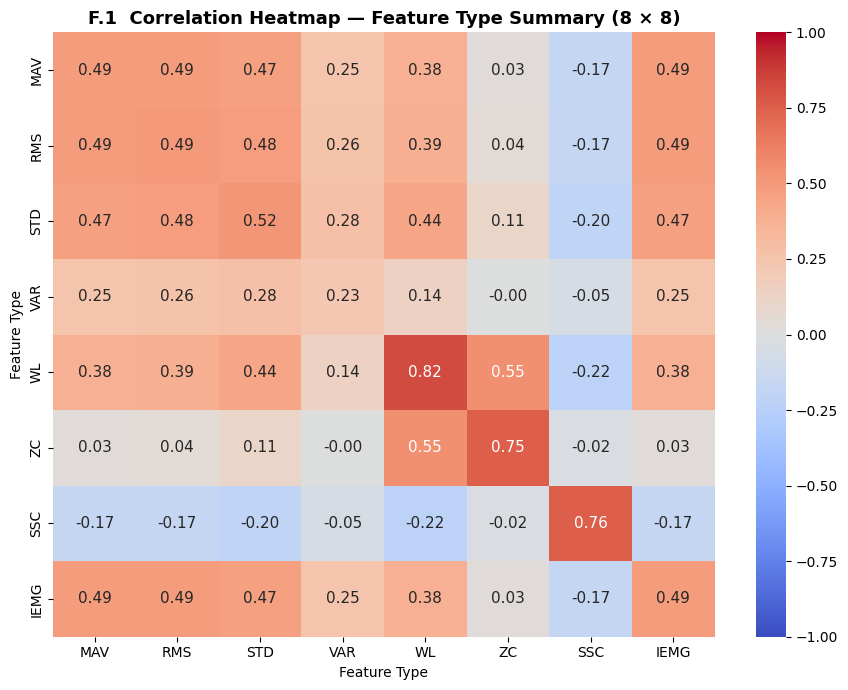

Reading: each cell shows the average correlation between two feature types
across all 24 EMG channels.
Values close to 1.0 = the two metrics carry very similar information.
MAV and IEMG are expected to be highly correlated — MAV = IEMG / window size.
ZC and SSC may correlate as both count signal direction changes.


In [26]:
# F.1  Correlation Heatmap — 8×8 summary (one value per feature type)
# Average the correlations across all 24 channels for each metric pair

METRICS = ["MAV", "RMS", "STD", "VAR", "WL", "ZC", "SSC", "IEMG"]

# Build 8×8 summary matrix
summary_corr = pd.DataFrame(index=METRICS, columns=METRICS, dtype=float)

for m1 in METRICS:
    for m2 in METRICS:
        # Get all 24 columns for m1 and all 24 columns for m2
        cols_m1 = [c for c in corr_matrix.columns if c.endswith(f"_{m1}")]
        cols_m2 = [c for c in corr_matrix.columns if c.endswith(f"_{m2}")]
        # Average the correlations between these two groups
        summary_corr.loc[m1, m2] = corr_matrix.loc[cols_m1, cols_m2].values.mean()

summary_corr = summary_corr.astype(float)

# Plot
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(summary_corr, cmap="coolwarm", center=0, vmin=-1, vmax=1,
            annot=True, fmt=".2f", annot_kws={"size": 11},
            xticklabels=METRICS, yticklabels=METRICS,
            ax=ax)
ax.set_title("F.1  Correlation Heatmap — Feature Type Summary (8 × 8)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Feature Type")
ax.set_ylabel("Feature Type")
plt.tight_layout()
plt.show()

print("Reading: each cell shows the average correlation between two feature types")
print("across all 24 EMG channels.")
print("Values close to 1.0 = the two metrics carry very similar information.")
print("MAV and IEMG are expected to be highly correlated — MAV = IEMG / window size.")
print("ZC and SSC may correlate as both count signal direction changes.")

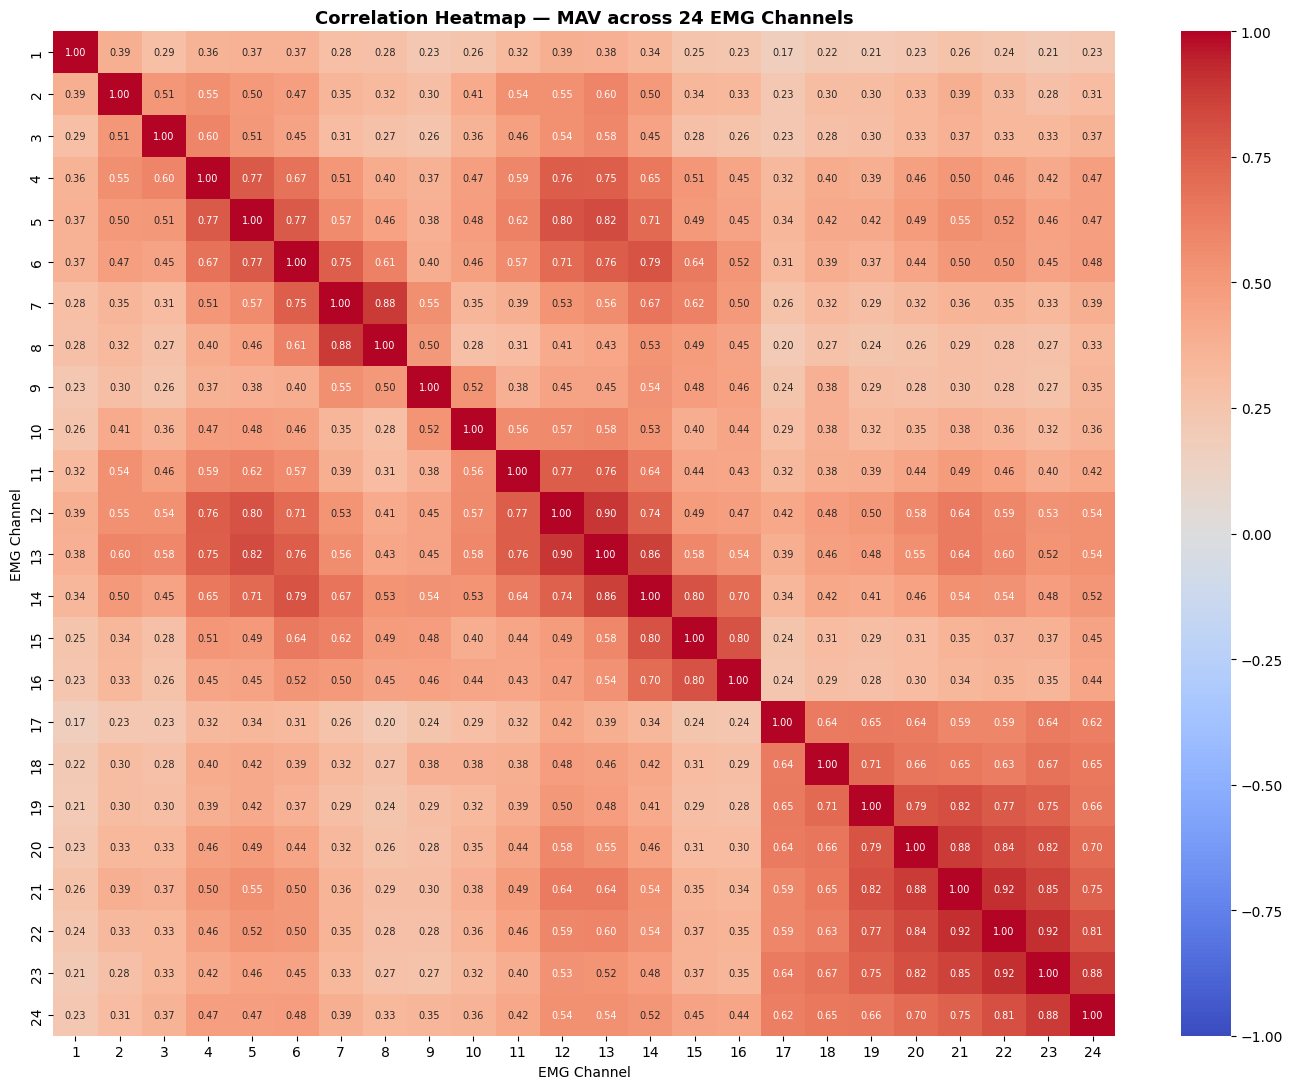

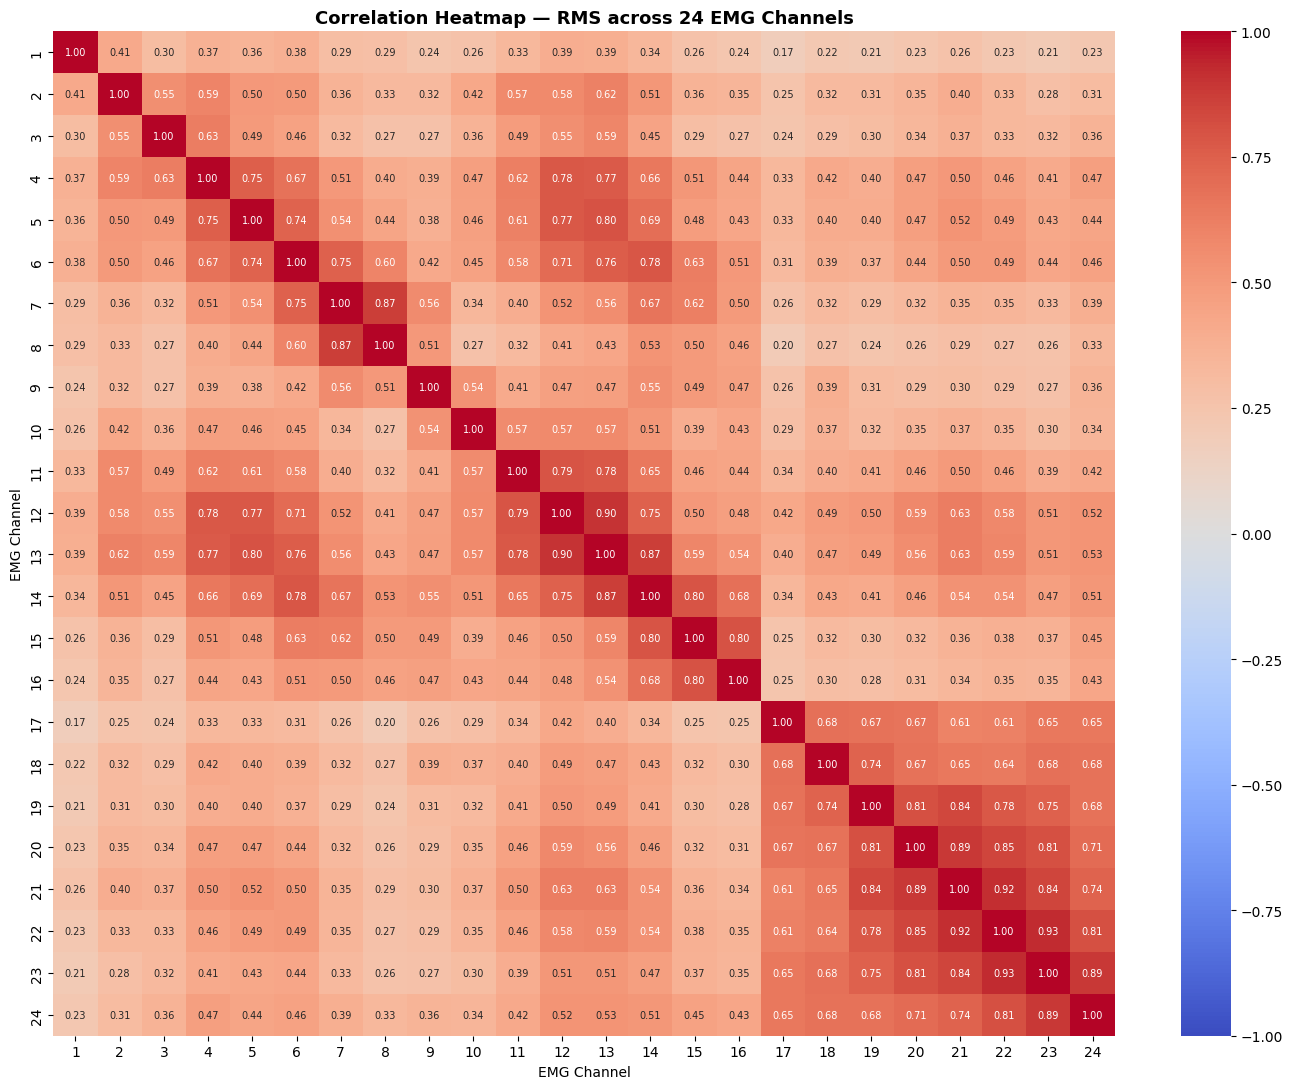

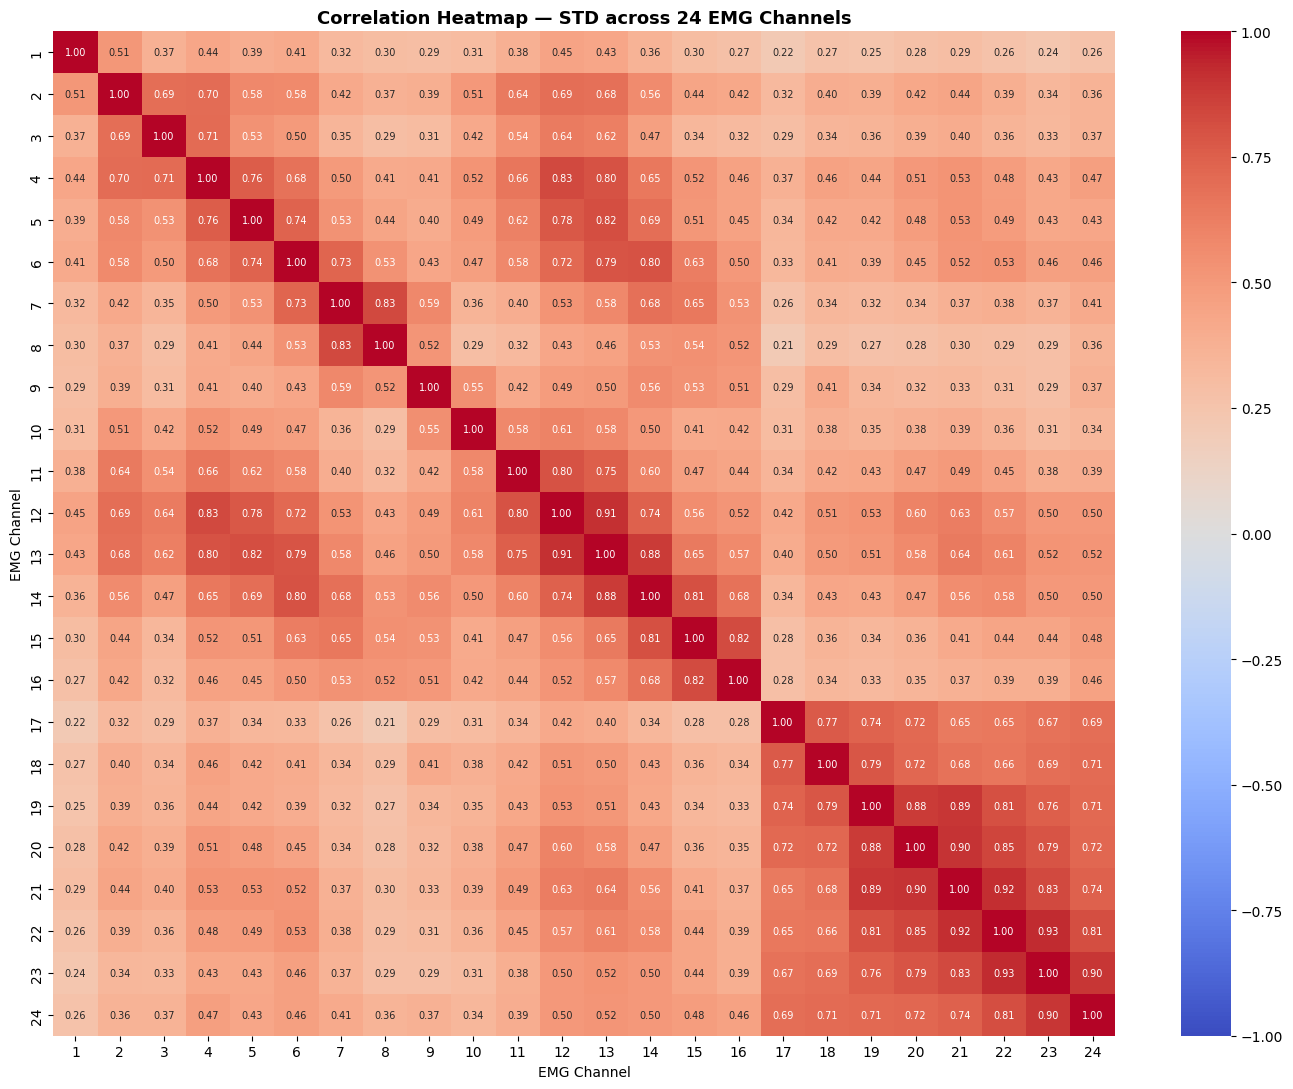

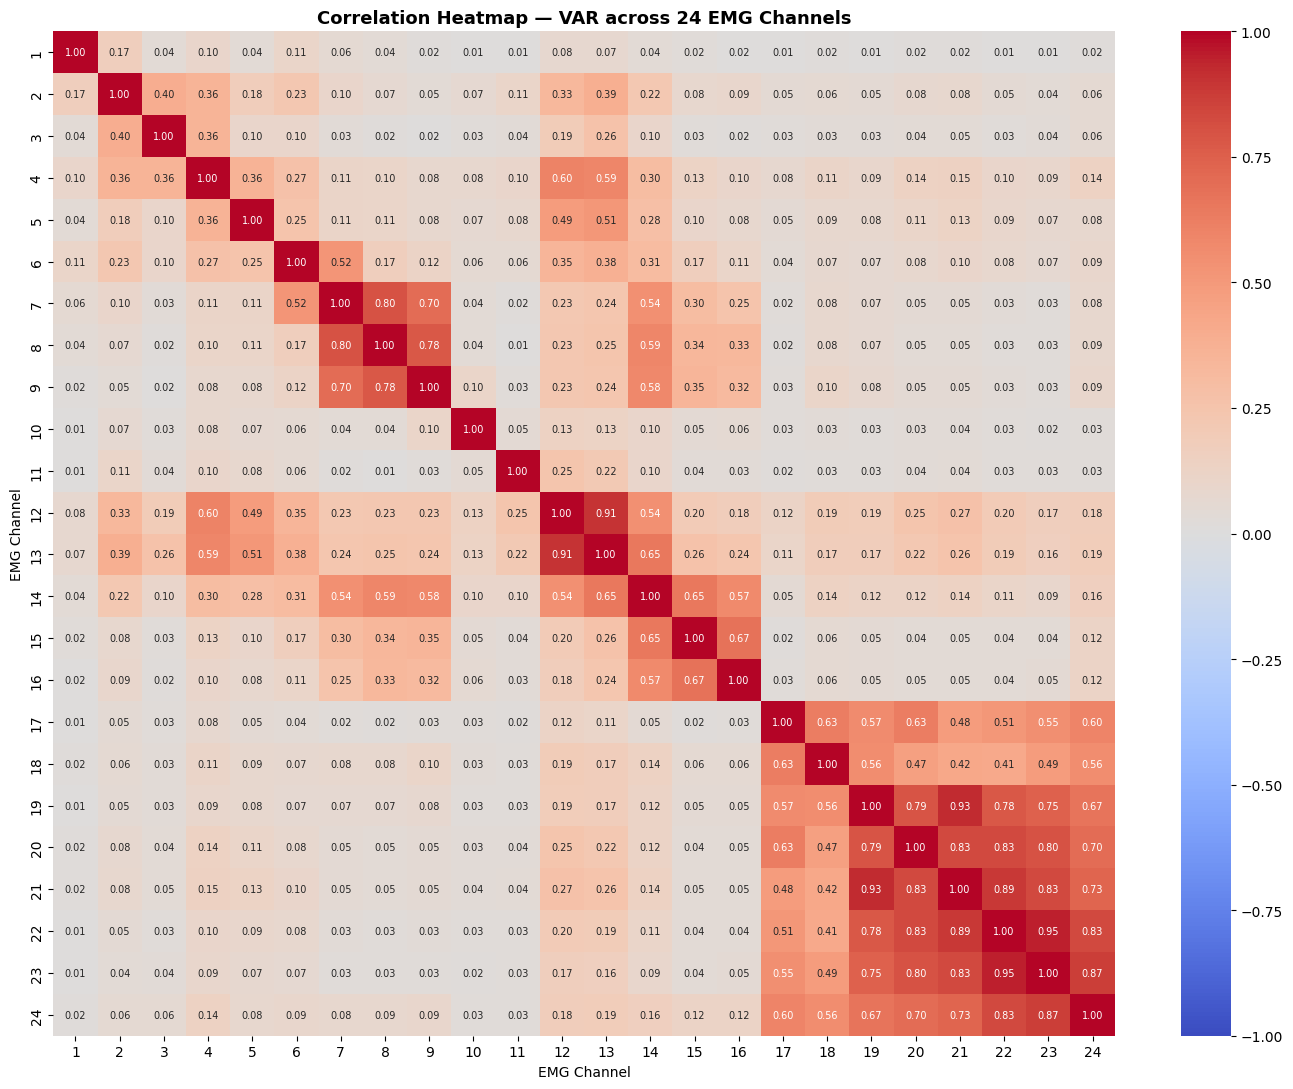

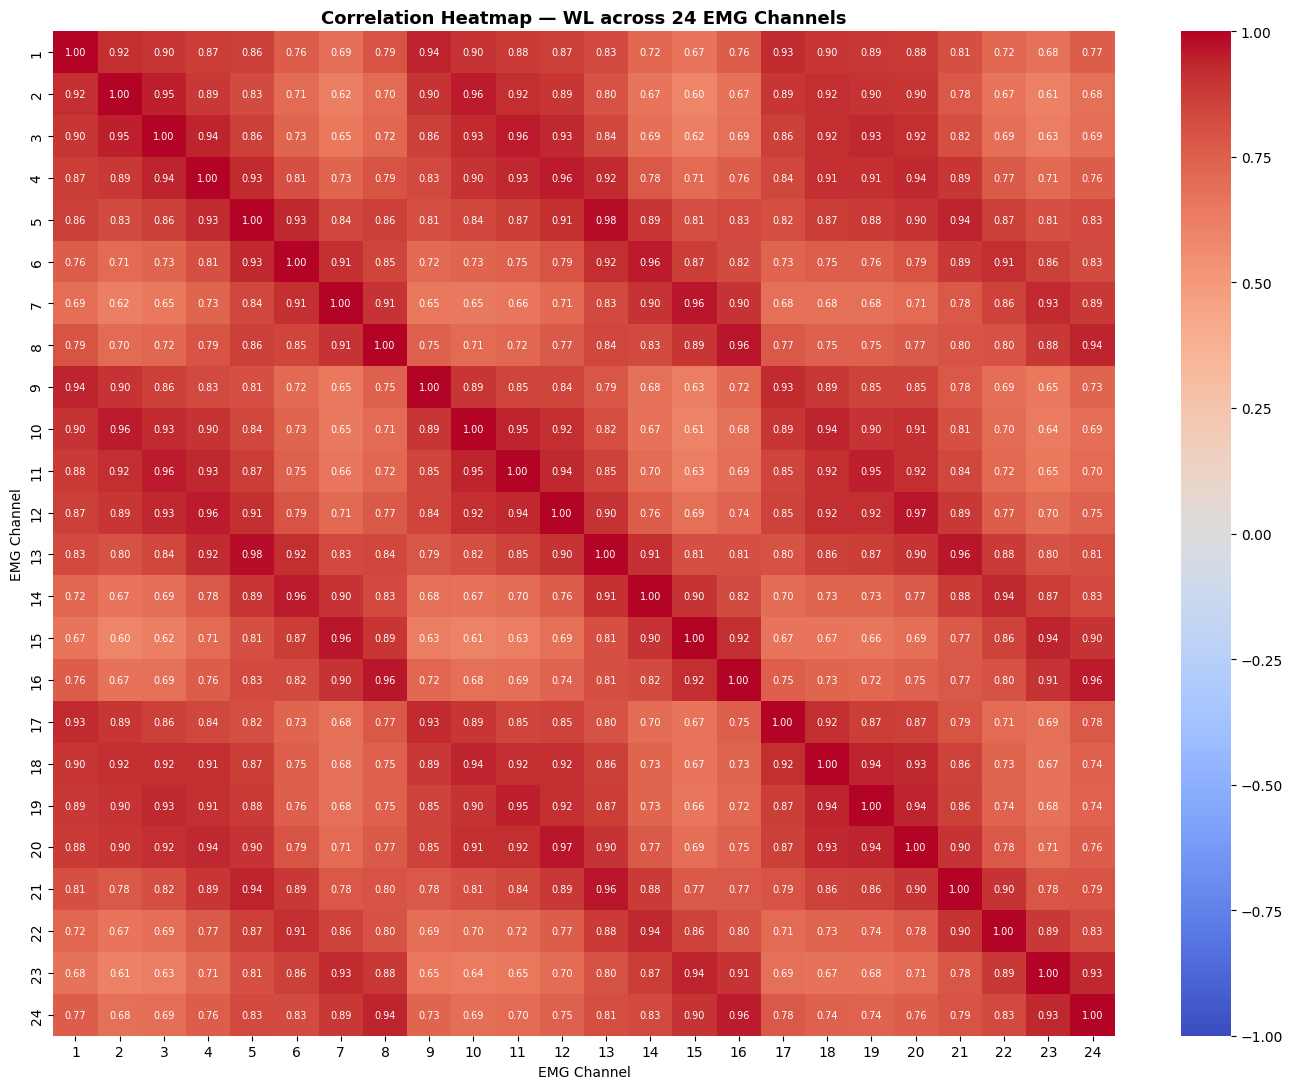

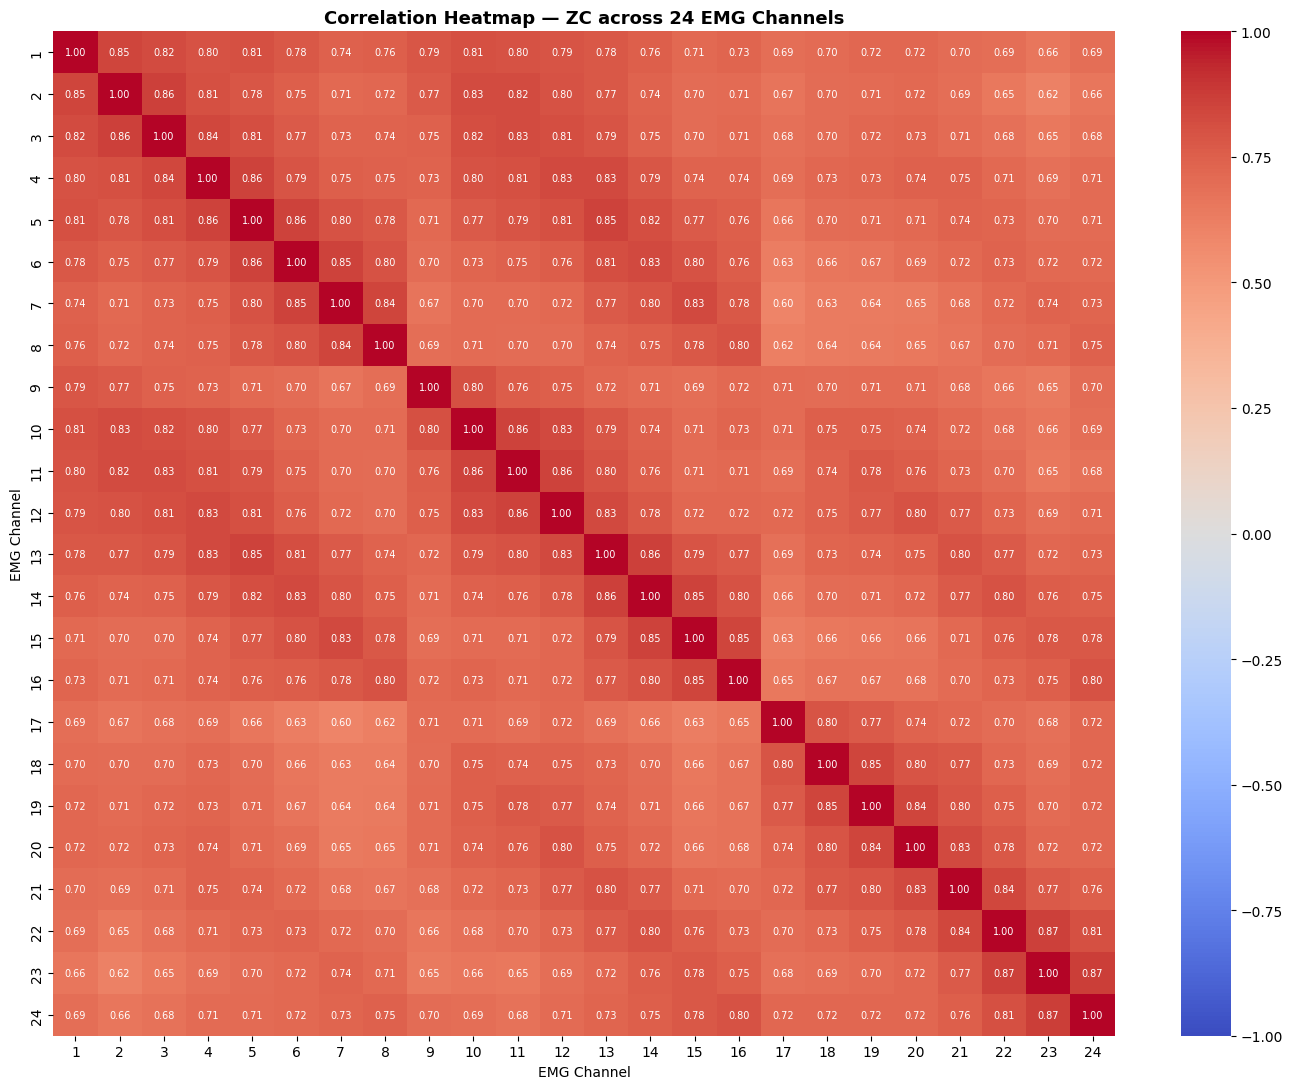

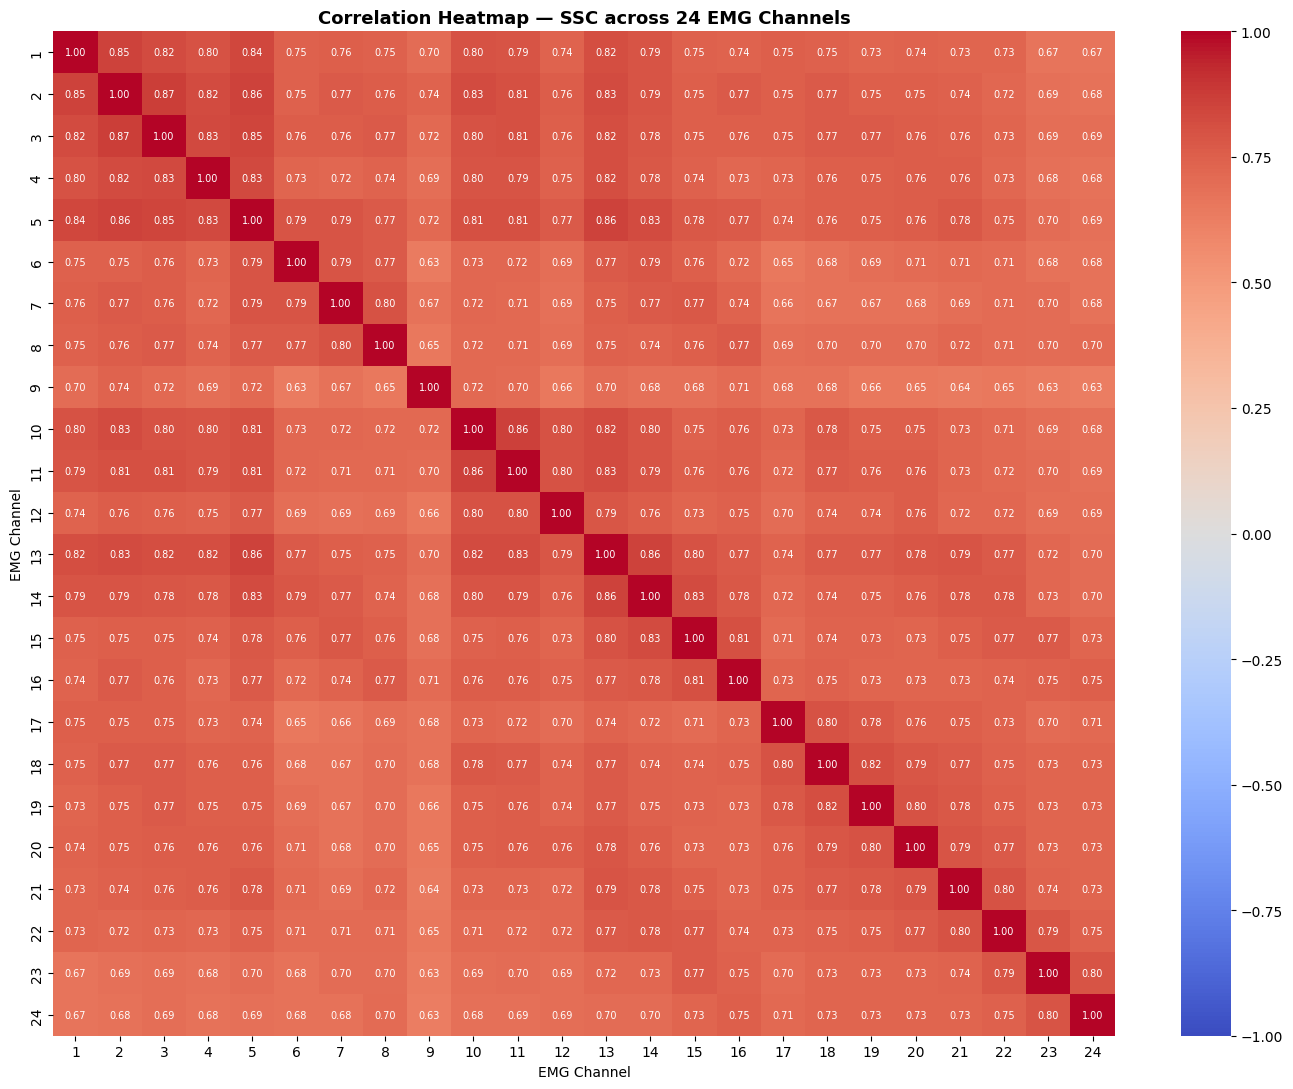

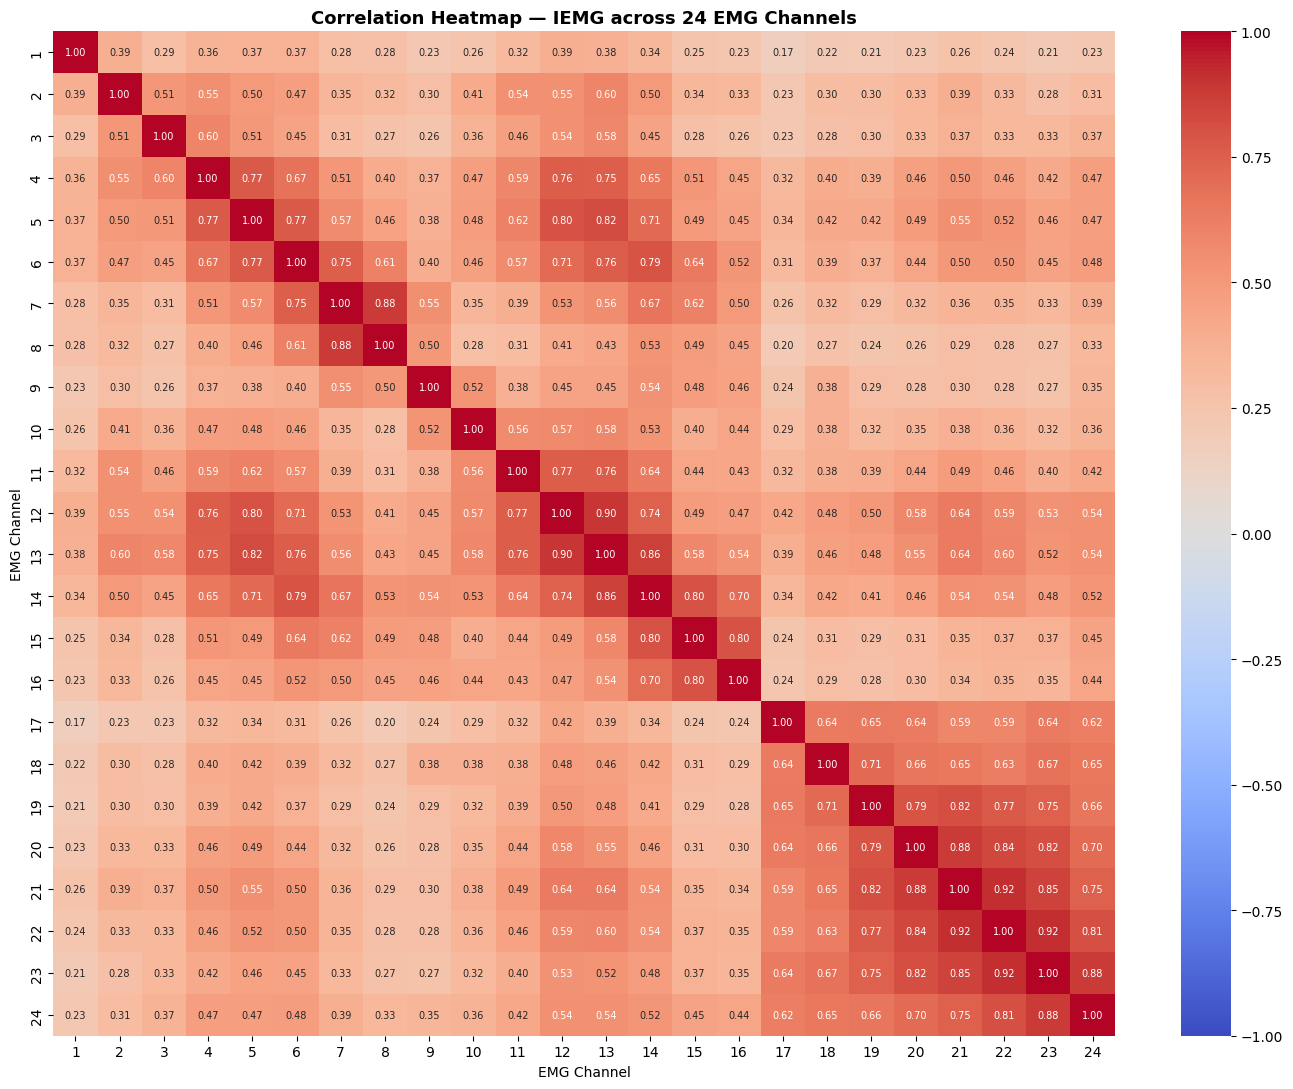

Reading: values close to 1.0 = highly correlated channels (adjacent electrodes).
Values close to 0 = independent channels. Negative values are rare in EMG.


In [13]:
# F.1  Annotated Correlation Heatmap — MAV across 24 channels
# Shows one feature type at a time with correlation values visible inside cells

METRICS   = ["MAV", "RMS", "STD", "VAR", "WL", "ZC", "SSC", "IEMG"]
EMG_CHANS = [c.replace("_MAV", "") for c in feat_cols if c.endswith("_MAV")]

for metric in METRICS:
    cols        = [f"{ch}_{metric}" for ch in EMG_CHANS if f"{ch}_{metric}" in corr_matrix.columns]
    sub         = corr_matrix.loc[cols, cols]
    tick_labels = [c.split("_")[1] for c in cols]   # "EMG_1_MAV" → "1"

    fig, ax = plt.subplots(figsize=(14, 11))
    sns.heatmap(sub, cmap="coolwarm", center=0, vmin=-1, vmax=1,
                annot=True, fmt=".2f", annot_kws={"size": 7},
                xticklabels=tick_labels, yticklabels=tick_labels,
                ax=ax)
    ax.set_title(f"Correlation Heatmap — {metric} across 24 EMG Channels",
                 fontsize=13, fontweight="bold")
    ax.set_xlabel("EMG Channel")
    ax.set_ylabel("EMG Channel")
    plt.tight_layout()
    plt.show()

print("Reading: values close to 1.0 = highly correlated channels (adjacent electrodes).")
print("Values close to 0 = independent channels. Negative values are rare in EMG.")

In [14]:
# F.2  Redundant feature list
THRESHOLD = 0.90
pairs = (
    upper.stack()
    .reset_index()
    .rename(columns={"level_0": "Feature_1", "level_1": "Feature_2", 0: "Abs_r"})
)
high_corr = pairs[pairs["Abs_r"] > THRESHOLD].sort_values("Abs_r", ascending=False).reset_index(drop=True)
print(f"F.2  Feature pairs with |r| > {THRESHOLD}: {len(high_corr)}")
display(high_corr.head(20))

# Greedy candidate list: mark the second feature in each highly-correlated pair
kept, redundant = [], []
for col in feat_cols:
    if any(corr_matrix.abs().loc[col, k] > THRESHOLD for k in kept):
        redundant.append(col)
    else:
        kept.append(col)
redundant_df = pd.DataFrame({
    "Candidate_redundant_feature": redundant
})

display(redundant_df)

high_corr.to_csv(
    "/kaggle/working/F_highly_correlated_feature_pairs.csv",
    index=False
)

redundant_df.to_csv(
    "/kaggle/working/F_candidate_redundant_features.csv",
    index=False
)

print("Saved full correlated-pair and redundant-feature lists.")

F.2  Feature pairs with |r| > 0.9: 209


,Feature_1,Feature_2,Abs_r
0,EMG_1_MAV,EMG_1_IEMG,1.0
1,EMG_5_MAV,EMG_5_IEMG,1.0
2,EMG_2_MAV,EMG_2_IEMG,1.0
3,EMG_3_MAV,EMG_3_IEMG,1.0
4,EMG_4_MAV,EMG_4_IEMG,1.0
5,EMG_6_MAV,EMG_6_IEMG,1.0
6,EMG_20_MAV,EMG_20_IEMG,1.0
7,EMG_18_MAV,EMG_18_IEMG,1.0
8,EMG_17_MAV,EMG_17_IEMG,1.0
9,EMG_14_MAV,EMG_14_IEMG,1.0


,Candidate_redundant_feature
0,EMG_22_MAV
1,EMG_1_RMS
2,EMG_2_RMS
3,EMG_3_RMS
4,EMG_4_RMS
...,...
76,EMG_20_IEMG
77,EMG_21_IEMG
78,EMG_22_IEMG
79,EMG_23_IEMG


Saved full correlated-pair and redundant-feature lists.



## G — Dimensionality Reduction (PCA / t-SNE / UMAP)

In [15]:
!pip install -q umap-learn
import umap.umap_ as umap_lib

# Stratified sample — 1 000 windows per class
proj_df = pd.concat(
    [g.sample(min(1000, len(g)), random_state=RANDOM_STATE)
     for _, g in feature_df.groupby("label", observed=True)],
    ignore_index=True,
).dropna(subset=feat_cols).reset_index(drop=True)
proj_df["Gesture"] = proj_df["label"].map(GESTURE_NAMES)

X  = proj_df[feat_cols].to_numpy(dtype="float32")
y  = proj_df["label"].to_numpy()
gn = proj_df["Gesture"].to_numpy()

# Standardise — required because feature scales differ greatly
X_sc  = StandardScaler().fit_transform(X).astype("float32")

# Pre-reduce to 50 PCA dims for t-SNE / UMAP speed (retains most variance)
pca_pre = PCA(n_components=min(50, X_sc.shape[1]), random_state=RANDOM_STATE)
X_pre   = pca_pre.fit_transform(X_sc).astype("float32")
print(f"Projection dataset  : {X.shape[0]} samples × {X.shape[1]} features")
print(f"PCA pre-reduction   : retains {pca_pre.explained_variance_ratio_.sum()*100:.1f}% variance")


def scatter2d(emb, names, xlab, ylab, title):
    """Simple 2-D scatter coloured by gesture class."""
    df_ = pd.DataFrame({xlab: emb[:, 0], ylab: emb[:, 1], "Gesture": names})
    fig, ax = plt.subplots(figsize=(10, 7))
    for g in sorted(df_["Gesture"].unique()):
        m = df_["Gesture"] == g
        ax.scatter(df_.loc[m, xlab], df_.loc[m, ylab], s=12, alpha=0.55, label=g)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel(xlab); ax.set_ylabel(ylab)
    ax.legend(fontsize=7, ncol=2, markerscale=2)
    plt.tight_layout(); plt.show()


def sil(emb, labels, name):
    """Silhouette score — higher = better class separation in the embedding."""
    sc = silhouette_score(emb, labels,
                          sample_size=min(5000, len(emb)),
                          random_state=RANDOM_STATE)
    print(f"  Silhouette ({name}) : {sc:.4f}")
    return sc

def scatter3d(emb, names, xlab, ylab, zlab, title):
    """3-D scatter coloured by gesture class."""
    df_ = pd.DataFrame({
        xlab: emb[:, 0],
        ylab: emb[:, 1],
        zlab: emb[:, 2],
        "Gesture": names,
    })

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection="3d")

    for gesture in sorted(df_["Gesture"].unique()):
        mask = df_["Gesture"] == gesture

        ax.scatter(
            df_.loc[mask, xlab],
            df_.loc[mask, ylab],
            df_.loc[mask, zlab],
            s=10,
            alpha=0.50,
            label=gesture,
        )

    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel(xlab)
    ax.set_ylabel(ylab)
    ax.set_zlabel(zlab)
    ax.legend(fontsize=7, ncol=2)

    plt.tight_layout()
    plt.show()

Projection dataset  : 8000 samples × 192 features
PCA pre-reduction   : retains 95.6% variance


G.1  PCA


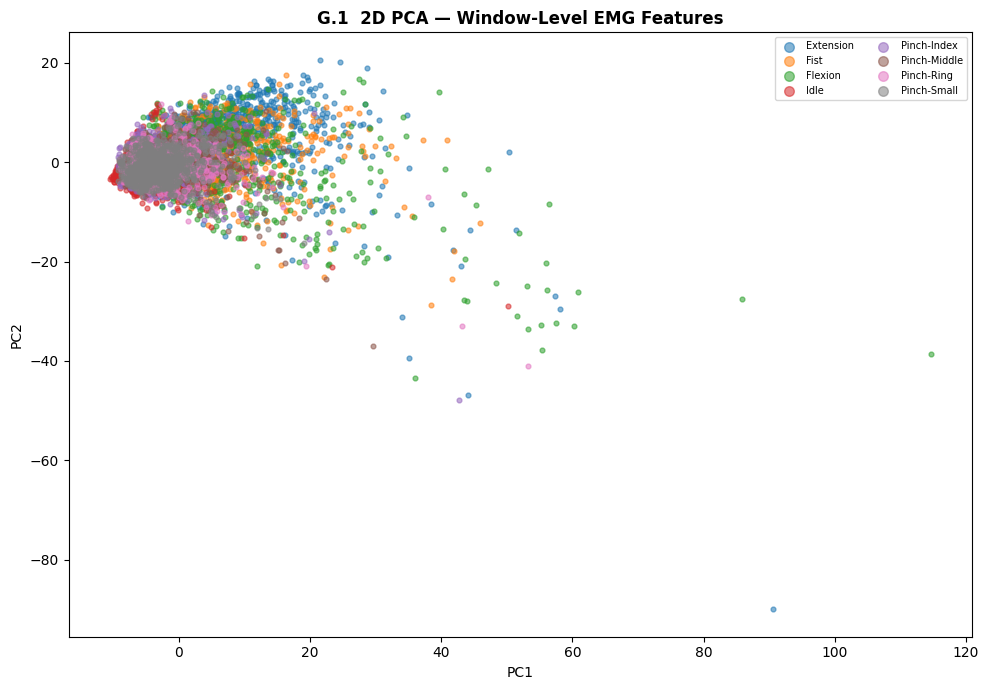

  Variance explained — PC1: 33.2%  PC2: 13.4%  PC3: 8.6%  (total 3 PCs: 55.2%)


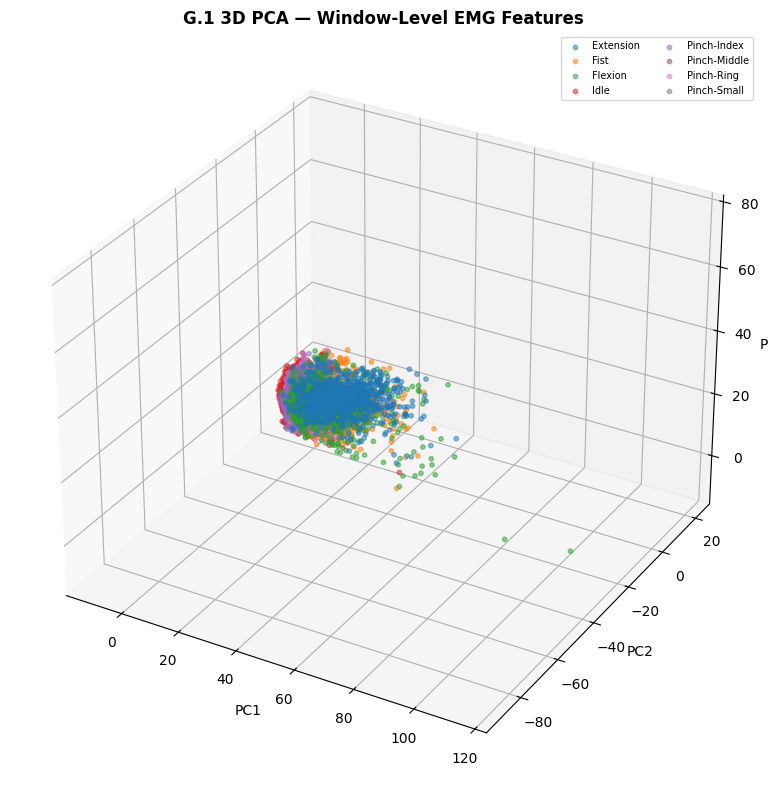

  Silhouette (PCA 2D) : -0.1199
  Silhouette (PCA 3D) : -0.0942
  Reading: PCA captures only linear structure. If most variance falls in 2-3
  PCs but classes still overlap, the class-discriminative structure is nonlinear.


In [16]:
# G.1  PCA
print("G.1  PCA")
pca3  = PCA(n_components=3, random_state=RANDOM_STATE)
E_pca = pca3.fit_transform(X_sc)
var   = pca3.explained_variance_ratio_ * 100

scatter2d(E_pca, gn, "PC1", "PC2", "G.1  2D PCA — Window-Level EMG Features")
print(f"  Variance explained — PC1: {var[0]:.1f}%  PC2: {var[1]:.1f}%  PC3: {var[2]:.1f}%"
      f"  (total 3 PCs: {var.sum():.1f}%)")
scatter3d(
    E_pca,
    gn,
    "PC1",
    "PC2",
    "PC3",
    "G.1 3D PCA — Window-Level EMG Features",
)
sc_pca2 = sil(E_pca[:, :2], y, "PCA 2D")
sc_pca3 = sil(E_pca,         y, "PCA 3D")
print("  Reading: PCA captures only linear structure. If most variance falls in 2-3")
print("  PCs but classes still overlap, the class-discriminative structure is nonlinear.")

G.2  t-SNE


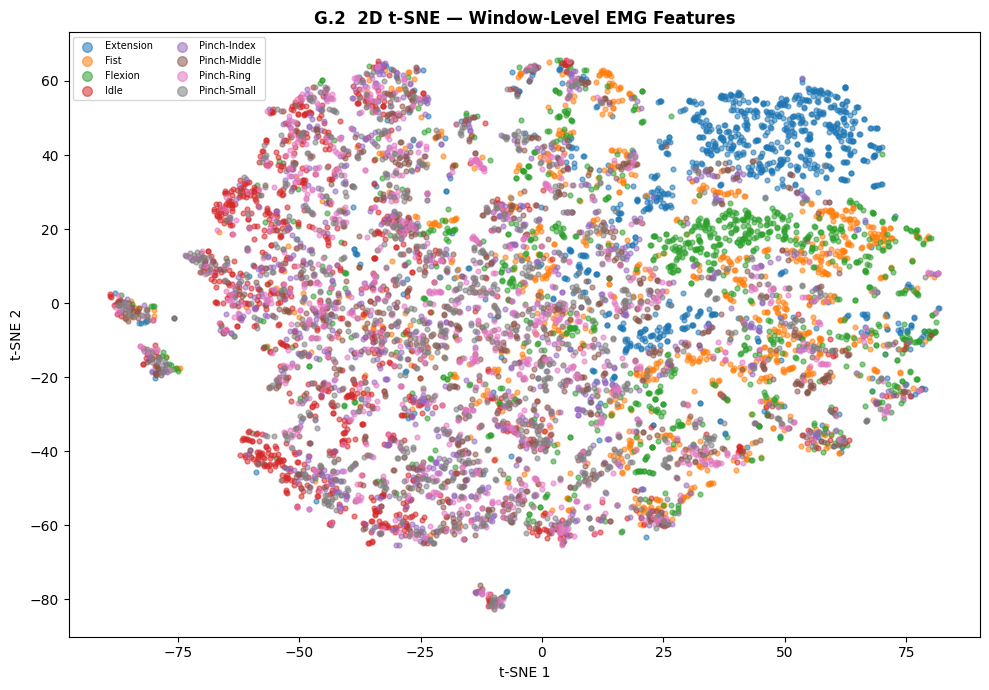

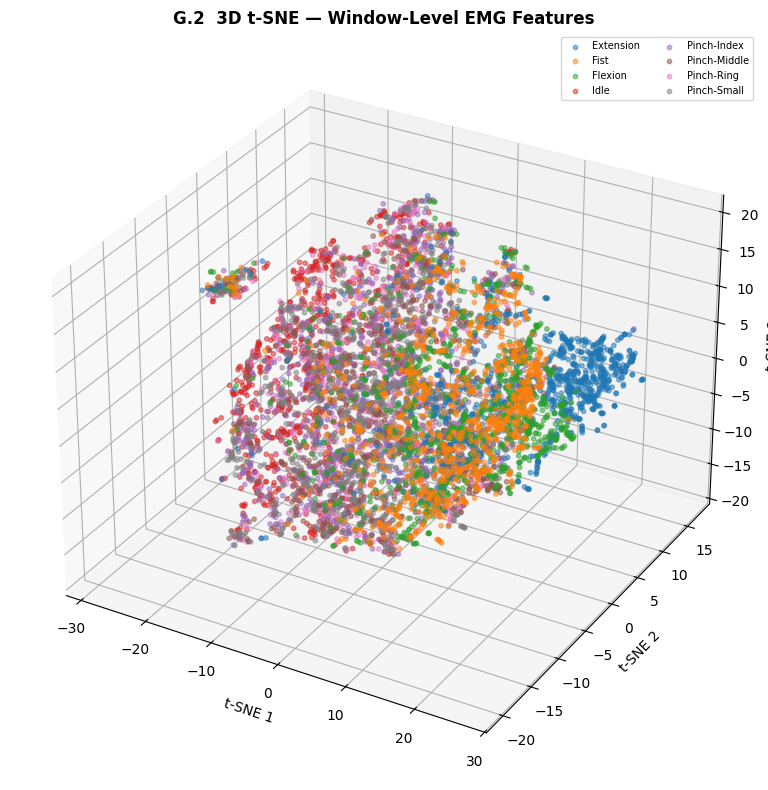

  Silhouette (t-SNE 2D) : -0.0666
  Silhouette (t-SNE 3D) : -0.0493
  Reading: t-SNE preserves local neighbourhood structure.
  Visible clusters suggest that class-discriminative patterns may exist
  that were not clearly visible in the linear PCA projection.
  However, t-SNE cluster distances and shapes should be interpreted
  cautiously because they depend on parameters and initialization.


In [17]:
# G.2  t-SNE
print("G.2  t-SNE")

perp = min(30, (len(X_pre) - 1) // 3)

E_tsne2 = TSNE(
    n_components=2,
    perplexity=perp,
    init="pca",
    learning_rate="auto",
    max_iter=1000,
    random_state=RANDOM_STATE,
).fit_transform(X_pre)

E_tsne3 = TSNE(
    n_components=3,
    perplexity=perp,
    init="pca",
    learning_rate="auto",
    max_iter=1000,
    random_state=RANDOM_STATE,
).fit_transform(X_pre)

# 2D t-SNE plot
scatter2d(
    E_tsne2,
    gn,
    "t-SNE 1",
    "t-SNE 2",
    "G.2  2D t-SNE — Window-Level EMG Features",
)

# 3D t-SNE plot
scatter3d(
    E_tsne3,
    gn,
    "t-SNE 1",
    "t-SNE 2",
    "t-SNE 3",
    "G.2  3D t-SNE — Window-Level EMG Features",
)

# Silhouette scores
sc_tsne2 = sil(
    E_tsne2,
    y,
    "t-SNE 2D",
)

sc_tsne3 = sil(
    E_tsne3,
    y,
    "t-SNE 3D",
)

print("  Reading: t-SNE preserves local neighbourhood structure.")
print("  Visible clusters suggest that class-discriminative patterns may exist")
print("  that were not clearly visible in the linear PCA projection.")
print("  However, t-SNE cluster distances and shapes should be interpreted")
print("  cautiously because they depend on parameters and initialization.")

G.3  UMAP


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



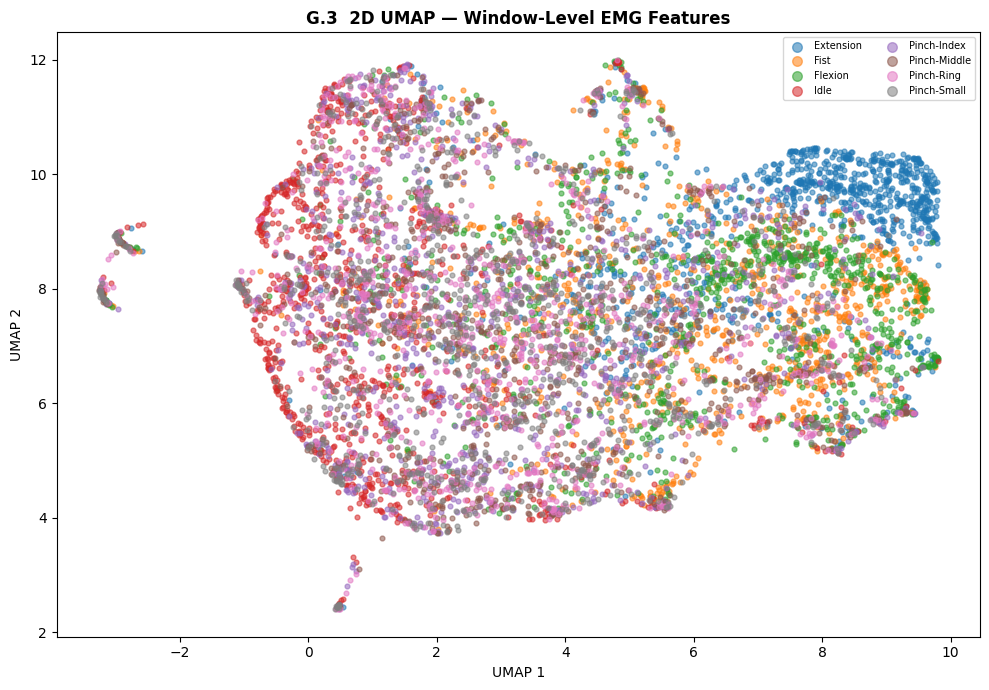

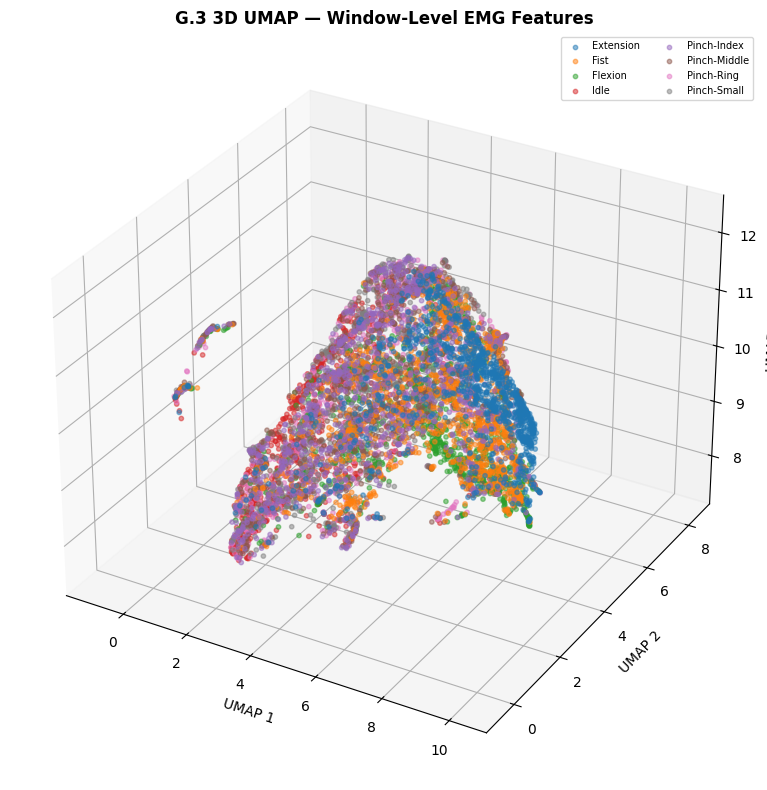

  Silhouette (UMAP 2D) : -0.0775
  Silhouette (UMAP 3D) : -0.0672
  Reading: UMAP balances local and global structure better than t-SNE.
  A higher silhouette than PCA confirms nonlinear class-separable structure.


In [18]:
# G.3  UMAP
print("G.3  UMAP")
E_umap2 = umap_lib.UMAP(n_components=2, n_neighbors=30, min_dist=0.1,
                          random_state=RANDOM_STATE).fit_transform(X_pre)
E_umap3 = umap_lib.UMAP(n_components=3, n_neighbors=30, min_dist=0.1,
                          random_state=RANDOM_STATE).fit_transform(X_pre)

scatter2d(E_umap2, gn, "UMAP 1", "UMAP 2", "G.3  2D UMAP — Window-Level EMG Features")
scatter3d(
    E_umap3,
    gn,
    "UMAP 1",
    "UMAP 2",
    "UMAP 3",
    "G.3 3D UMAP — Window-Level EMG Features",
)
sc_umap2 = sil(E_umap2, y, "UMAP 2D")
sc_umap3 = sil(E_umap3, y, "UMAP 3D")
print("  Reading: UMAP balances local and global structure better than t-SNE.")
print("  A higher silhouette than PCA confirms nonlinear class-separable structure.")

In [19]:
# G.4  Comparison table
comp = pd.DataFrame({
    "Method"          : ["PCA 2D", "PCA 3D", "t-SNE 2D", "t-SNE 3D", "UMAP 2D", "UMAP 3D"],
    "Silhouette Score": [ sc_pca2,  sc_pca3,   sc_tsne2,   sc_tsne3,   sc_umap2,  sc_umap3],
}).sort_values("Silhouette Score", ascending=False).reset_index(drop=True)

display(comp.round(4))
highest = comp.iloc[0]

print(
    f"Highest descriptive embedding-space silhouette: "
    f"{highest['Method']} "
    f"({highest['Silhouette Score']:.4f})"
)

print()
print("Interpretation:")
print("  • These scores describe class compactness in each generated embedding.")
print("  • They are not classification accuracy and should not select the final model.")
print("  • The 2D and 3D t-SNE/UMAP embeddings were fitted independently, so a")
print("    higher 3D score cannot be attributed only to adding one extra axis.")
print("  • Final model performance must be evaluated in the original feature space")
print("    using subject-grouped validation.")
print()
print("Important: overlapping classes in 2-D do not mean classification is impossible.")
print("Classifiers operate in the full 192-D feature space where separation is stronger.")
print("Silhouette scores here measure 2-D / 3-D structure only, not classification accuracy.")

,Method,Silhouette Score
0,t-SNE 3D,-0.0493
1,t-SNE 2D,-0.0666
2,UMAP 3D,-0.0672
3,UMAP 2D,-0.0775
4,PCA 3D,-0.0942
5,PCA 2D,-0.1199


Highest descriptive embedding-space silhouette: t-SNE 3D (-0.0493)

Interpretation:
  • These scores describe class compactness in each generated embedding.
  • They are not classification accuracy and should not select the final model.
  • The 2D and 3D t-SNE/UMAP embeddings were fitted independently, so a
    higher 3D score cannot be attributed only to adding one extra axis.
  • Final model performance must be evaluated in the original feature space
    using subject-grouped validation.

Important: overlapping classes in 2-D do not mean classification is impossible.
Classifiers operate in the full 192-D feature space where separation is stronger.
Silhouette scores here measure 2-D / 3-D structure only, not classification accuracy.



## H — Interactive Plots (Plotly)

In [20]:
# Attach all embeddings to one dataframe so hover works consistently
hover_base = proj_df[["label", "subject_id", "experiment_type", "Gesture"]].copy()
hover_base["Gesture"] = hover_base["Gesture"].astype(str)

idf = hover_base.copy()
idf[["PC1",   "PC2",   "PC3"]]   = E_pca
idf[["TSNE1", "TSNE2"]]          = E_tsne2
idf[["UMAP2D_1", "UMAP2D_2"]] = E_umap2

idf[
    ["UMAP3D_1", "UMAP3D_2", "UMAP3D_3"]
] = E_umap3

hover_cols = ["label", "subject_id", "experiment_type"]
print("Interactive dataframe ready — all embeddings attached.")

Interactive dataframe ready — all embeddings attached.


In [21]:
# H.1  Interactive 2D PCA
fig = px.scatter(
    idf, x="PC1", y="PC2", color="Gesture",
    hover_data=hover_cols, opacity=0.65, render_mode="webgl",
    title="H.1  Interactive 2D PCA — Window-Level EMG Features",
    labels={"PC1": "Principal Component 1", "PC2": "Principal Component 2"},
)
fig.update_traces(marker_size=4)
fig.update_layout(title_x=0.5, legend_title_text="Gesture Class")
fig.show()
print("Reading: overlap in PC1 and PC2 means that the first two maximum-variance")
print("linear directions do not visually separate all gesture classes.")
print("This does not prove that linear classification will fail, because supervised")
print("linear models can use all 192 features and directions that PCA did not display.")
print("Linear and nonlinear classifiers must be compared through grouped validation.")

Reading: overlap in PC1 and PC2 means that the first two maximum-variance
linear directions do not visually separate all gesture classes.
This does not prove that linear classification will fail, because supervised
linear models can use all 192 features and directions that PCA did not display.
Linear and nonlinear classifiers must be compared through grouped validation.


In [22]:
# H.2  Interactive 2D UMAP
fig = px.scatter(
    idf, x="UMAP2D_1", y="UMAP2D_2", color="Gesture",
    hover_data=hover_cols, opacity=0.65, render_mode="webgl",
    title="H.2  Interactive 2D UMAP — Window-Level EMG Features",
    labels={
    "UMAP2D_1": "UMAP Dimension 1",
    "UMAP2D_2": "UMAP Dimension 2",},
)
fig.update_traces(marker_size=4)
fig.update_layout(title_x=0.5, legend_title_text="Gesture Class")
fig.show()
print("Reading: hover over any point to see its subject and recording type.")
print("If visible clusters align more with subject_id than Gesture, this flags")
print("high inter-subject variability — a known challenge in EMG classification.")

Reading: hover over any point to see its subject and recording type.
If visible clusters align more with subject_id than Gesture, this flags
high inter-subject variability — a known challenge in EMG classification.


In [23]:
# H.3  Interactive 3D UMAP
fig = px.scatter_3d(
    idf,
x="UMAP3D_1",
y="UMAP3D_2",
z="UMAP3D_3",
color="Gesture",
    hover_data=hover_cols, opacity=0.65,
    title="H.3  Interactive 3D UMAP — Window-Level EMG Features",
    labels={
    "UMAP3D_1": "UMAP 3D Dimension 1",
    "UMAP3D_2": "UMAP 3D Dimension 2",
    "UMAP3D_3": "UMAP 3D Dimension 3",},
)
fig.update_traces(marker_size=3)
fig.update_layout(title_x=0.5, legend_title_text="Gesture Class")
fig.show()
print("Reading: rotate the 3D view to inspect gesture overlap from different angles.")
print("The 2D and 3D UMAP models were fitted independently. Therefore, a higher")
print("3D silhouette is descriptive, but it does not isolate the contribution of")
print("only the third coordinate.")

Reading: rotate the 3D view to inspect gesture overlap from different angles.
The 2D and 3D UMAP models were fitted independently. Therefore, a higher
3D silhouette is descriptive, but it does not isolate the contribution of
only the third coordinate.


In [24]:
# H.4 Interactive scatter — two selected representative features
xf, yf = rep_features[0], rep_features[1]   # e.g. EMG_1_MAV vs EMG_1_RMS
fdf = plot_df[["Gesture", "subject_id", "label", xf, yf]].copy()
fdf["Gesture"] = fdf["Gesture"].astype(str)

fig = px.scatter(
    fdf, x=xf, y=yf, color="Gesture",
    hover_data=["subject_id", "label"],
    opacity=0.60, render_mode="webgl",
    title=f"H.4  Interactive Feature Scatter — {xf}  vs  {yf}",
)
fig.update_traces(marker_size=4)
fig.update_layout(title_x=0.5, legend_title_text="Gesture Class")
fig.show()
print(f"Reading: this plot compares two representative features: {xf} and {yf}.")
print("Visible overlap means this particular feature pair does not provide complete")
print("class separation. It does not by itself determine separability in the full")
print("192-dimensional feature space.")

Reading: this plot compares two representative features: EMG_1_MAV and EMG_1_RMS.
Visible overlap means this particular feature pair does not provide complete
class separation. It does not by itself determine separability in the full
192-dimensional feature space.



## Save Final Feature Dataset

In [25]:
out = "/kaggle/working/putemg_window_feature_dataset.parquet"
feature_df.to_parquet(out, index=False)
print(f"Saved: {feature_df.shape}  →  {out}")

Saved: (619479, 196)  →  /kaggle/working/putemg_window_feature_dataset.parquet
